In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [3]:
dataset = baseClasses.Data()

In [4]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 4, 30)) & (dataset.data.index < datetime.datetime(2024, 5, 15))) |
    ((dataset.data.index > datetime.datetime(2024, 11, 20)) & (dataset.data.index < datetime.datetime(2024, 12, 10)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [5]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
apa = systemClasses.System(dataset=dataset, name="APA")
prm = systemClasses.System(dataset=dataset, name="PRM")
pipe = systemClasses.System(dataset=dataset, name="PIPE")
pp = systemClasses.System(dataset=dataset, name="PP")
hawai = systemClasses.System(dataset=dataset, name="HAWAI")

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00, 11.24sensor/s]


ERROR: Channel (TE0120) not found


Initializing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00, 11.39sensor/s]


In [6]:
tgrad.calibrate(calibName="SECOND_POFF_OCTOBER")
apa.calibrate(calibName="SECOND_POFF_OCTOBER")
prm.calibrate(calibName="SECOND_POFF_OCTOBER")
pipe.calibrate(calibName="SECOND_POFF_OCTOBER")
pp.calibrate(calibName="SECOND_POFF_OCTOBER")
hawai.calibrate(calibName="SECOND_POFF_EMPTY")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00,  9.98sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 48/48 [00:00<00:00, 104.92sensor/s]
Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 13.79sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 16/16 [00:00<00:00, 102.63sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  9.49sensor/s]
Calibrating PRM Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 6/6 [00:00<00:00, 100.90sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  9.34sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 62.29sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00, 10.38sensor/s]
Calibrating PP Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 94.03sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00, 10.94sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 24/24 [00:00<00:00, 104.62sensor/s]


In [120]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

ambient = sensorClasses.Sensor(dataset=dataset, id=1037)

# MUX1 and MUX2

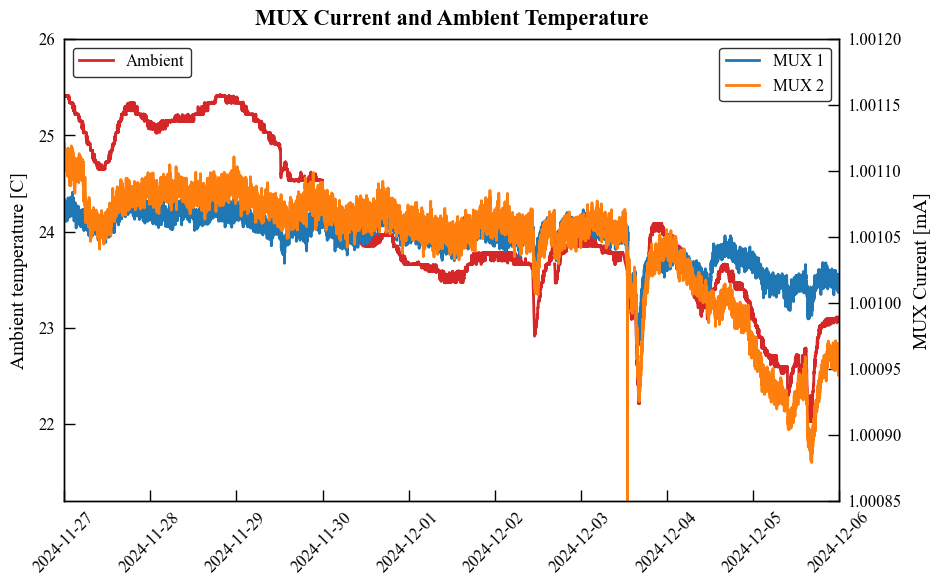

In [8]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
axes.plot(ambient.data.index.values, ambient.data.values, label="Ambient", color="tab:red")
axes.set_xlim(pd.Timestamp("2024-11-27"), pd.Timestamp("2024-12-06"))
axes.set_ylim(21.2, 26)
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
axes2.plot(mux1.data.index.values, mux1.data.values, label="MUX 1", color="tab:blue")
axes2.plot(mux2.data.index.values, mux2.data.values, label="MUX 2", color="tab:orange")
axes2.set_ylim(1.00085, 1.0012)
axes.set_ylabel("Ambient temperature [C]")
axes2.set_ylabel("MUX Current [mA]")
axes.set_title("MUX Current and Ambient Temperature")
axes.legend(loc="upper left")
axes2.legend(loc="upper right")
# axes2.plot((mux1.data-mux2.data).index.values, -(mux1.data-mux2.data).values, label="MUX 1 - MUX 2", color="tab:green")
# axes2.set_ylim(-0.00015, 0.00015)

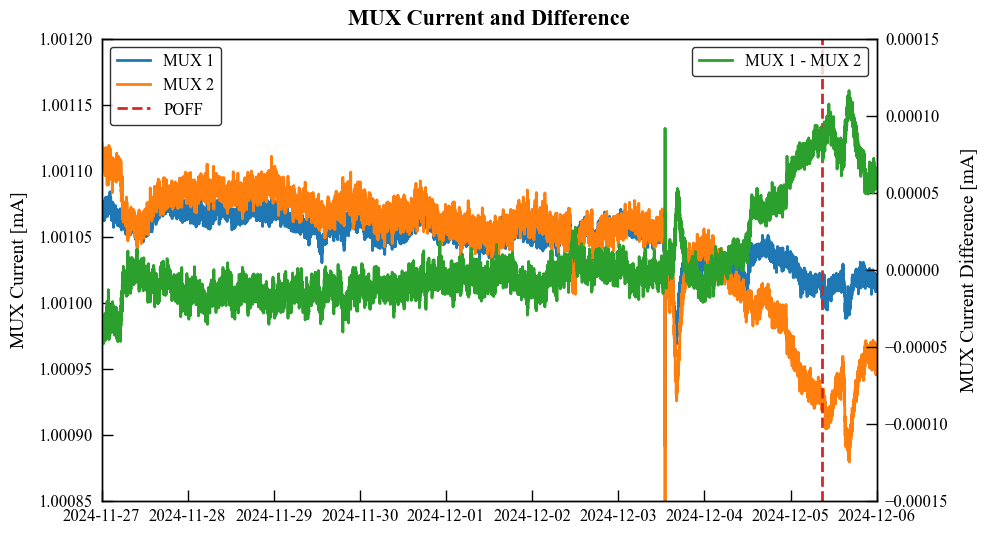

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
axes.plot(mux1.data.index.values, mux1.data.values, label="MUX 1", color="tab:blue")
axes.set_xlim(pd.Timestamp("2024-11-27"), pd.Timestamp("2024-12-06"))
axes.plot(mux2.data.index.values, mux2.data.values, label="MUX 2", color="tab:orange")
axes2 = axes.twinx()
axes2.plot((mux1.data-mux2.data).index.values, (mux1.data-mux2.data).values, label="MUX 1 - MUX 2", color="tab:green")
axes.set_ylim(1.00085, 1.0012)
axes2.set_ylim(-0.00015, 0.00015)
axes.axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")
axes.set_ylabel("MUX Current [mA]")
axes2.set_ylabel("MUX Current Difference [mA]")
axes.set_title("MUX Current and Difference")
axes.legend(loc="upper left")
axes2.legend(loc="upper right")

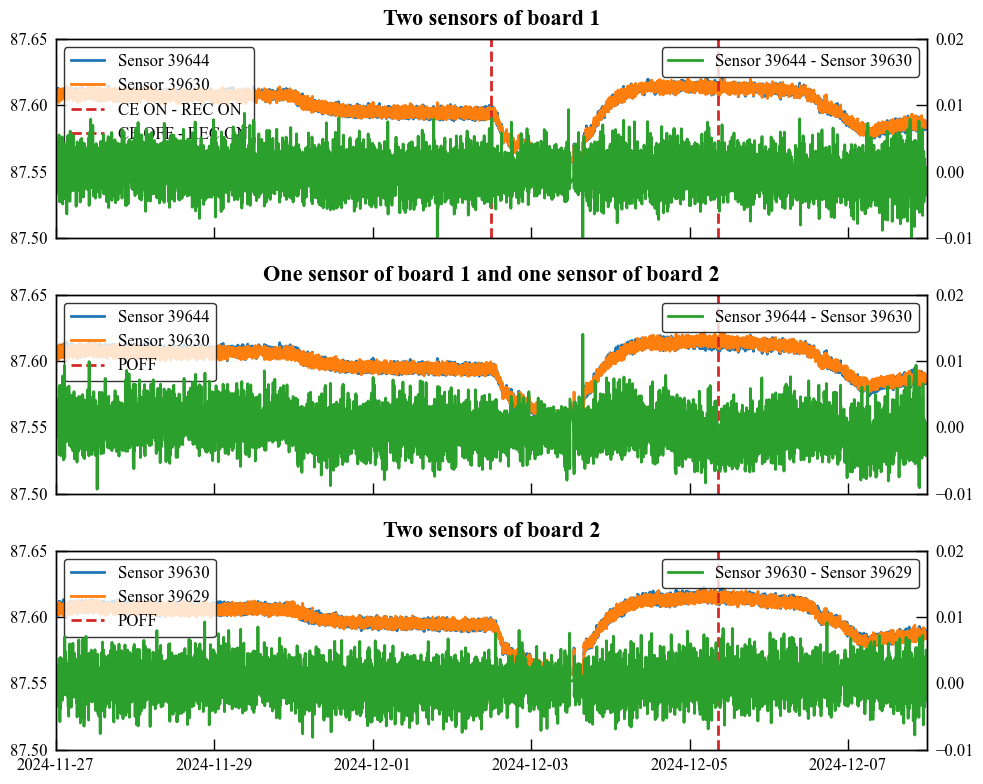

In [10]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True, sharey=True)
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39646).muxEqualization().tempCalibration(
    calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500"
    )
sensor2 = sensorClasses.Sensor(dataset=dataset, id=39644).muxEqualization().tempCalibration(
    calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500"
    )
axes[0].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 39644", color="tab:blue")
axes[0].set_xlim(pd.Timestamp("2024-11-27"), pd.Timestamp("2024-12-08"))
axes[0].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 39630", color="tab:orange")
# axes[0].set_ylim(87.6, 87.9)
axes2 = axes[0].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 39644 - Sensor 39630", color="tab:green")
axes2.set_ylim(-0.01, 0.02)
axes[0].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="CE ON - REC ON")
axes[0].axvline(pd.Timestamp("2024-12-02 11:45:00"), color="tab:red", linestyle="--", label="CE OFF - REC ON")
axes[0].legend(loc="upper left")
axes2.legend(loc="upper right")
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39644).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
sensor2 = sensorClasses.Sensor(dataset=dataset, id=39630).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
axes[1].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 39644", color="tab:blue")
# axes[1].set_xlim(pd.Timestamp("2024-11-29"), pd.Timestamp("2024-12-06"))
axes[1].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 39630", color="tab:orange")
# axes[1].set_ylim(87.64, 87.72)
axes2 = axes[1].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 39644 - Sensor 39630", color="tab:green")
axes2.set_ylim(-0.01, 0.02)
axes[1].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")
axes[1].legend(loc="upper left")
axes2.legend(loc="upper right")
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39630).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
sensor2 = sensorClasses.Sensor(dataset=dataset, id=39629).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
axes[2].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 39630", color="tab:blue")
# axes[2].set_xlim(pd.Timestamp("2024-11-29"), pd.Timestamp("2024-12-06"))
axes[2].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 39629", color="tab:orange")
axes[2].set_ylim(87.5, 87.65)
axes2 = axes[2].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 39630 - Sensor 39629", color="tab:green")
axes2.set_ylim(-0.01, 0.02)
axes[2].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")

axes[0].set_title("Two sensors of board 1")
axes[1].set_title("One sensor of board 1 and one sensor of board 2")
axes[2].set_title("Two sensors of board 2")
axes[2].legend(loc="upper left")
axes2.legend(loc="upper right")
fig.tight_layout()

In [181]:
sim = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMBasePD2.csv", header=0, names=["Y", "temp"])

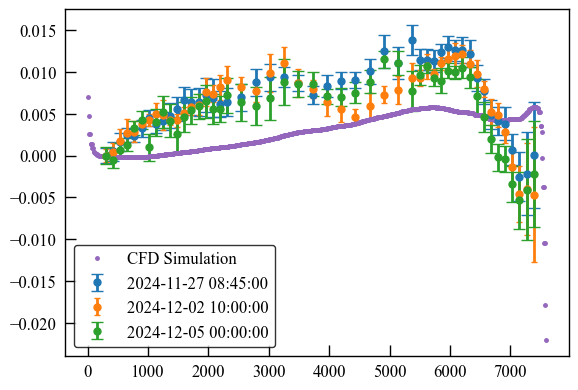

In [ ]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
# plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="2024-11-27 08:45:00")
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0], yerr=tgrad.profiles["err"].values, fmt='o', label="2024-11-27 08:45:00")
# tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 1, 1, 0, 0), tend=datetime.datetime(2024, 12, 1, 1, 15, 0))
# plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0], yerr=tgrad.profiles["err"].values, fmt='o', label="2024-12-11 01:00:00")
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 2, 11, 40, 0), tend=datetime.datetime(2024, 12, 2, 11, 45, 0))
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0], yerr=tgrad.profiles["err"].values, fmt='o', capsize=2.5, label="2024-12-02 10:00:00")
# tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 4, 0, 0, 0), tend=datetime.datetime(2024, 12, 4, 0, 15, 0))
# plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0], yerr=tgrad.profiles["err"].values, fmt='o', label="2024-12-04 08:45:00")
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 5, 0, 0, 0), tend=datetime.datetime(2024, 12, 5, 0, 15, 0))
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0], yerr=tgrad.profiles["err"].values, fmt='o', label="2024-12-05 00:00:00")
# tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 5, 9, 45, 0), tend=datetime.datetime(2024, 12, 5, 10, 0, 0))
# plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0], yerr=tgrad.profiles["err"].values, fmt='o', label="2024-12-05 08:45:00")
plt.plot(1e3*sim["Y"].values, sim["temp"].values - sim["temp"].loc[sim["Y"]==0.2].values[0], ".", label="CFD Simulation", color="tab:purple")
plt.legend()

# MUX1 and MUX3

1.0044276971442292


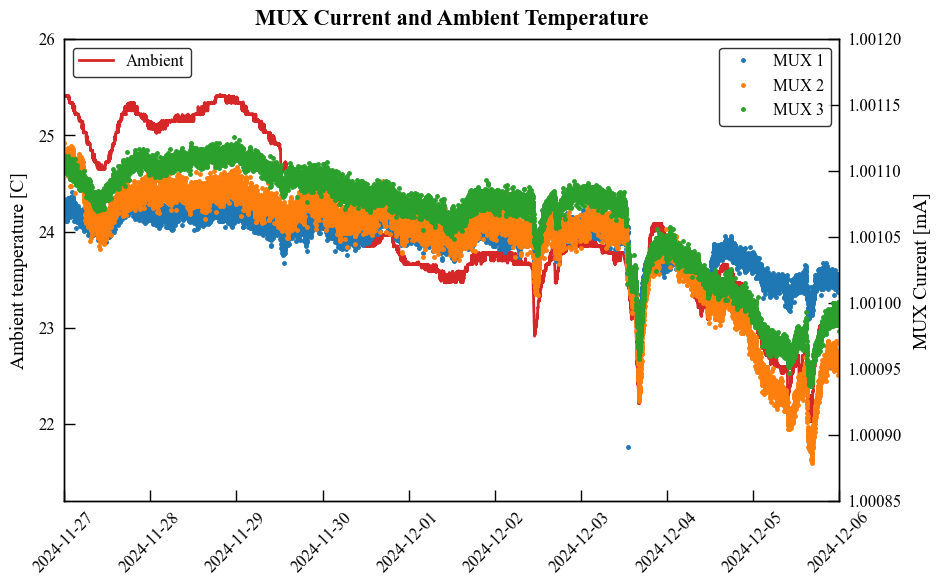

In [12]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
axes.plot(ambient.data.index.values, ambient.data.values, label="Ambient", color="tab:red")
axes.set_xlim(pd.Timestamp("2024-11-27"), pd.Timestamp("2024-12-06"))
axes.set_ylim(21.2, 26)
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
print(mux3.data.loc[(mux3.data.index > pd.Timestamp("2024-11-27")) & (mux3.data.index < pd.Timestamp("2024-12-06"))].mean())
axes2.plot(mux1.data.index.values, mux1.data.values, ".", label="MUX 1", color="tab:blue")
axes2.plot(mux2.data.index.values, mux2.data.values, ".", label="MUX 2", color="tab:orange")
axes2.plot(mux3.data.index.values, mux3.data.values + 0.0003, ".", label="MUX 3", color="tab:green")
# axes2.set_ylim(1.00085, 1.0012)
axes2.set_ylim(1.00085, 1.0012)
axes.set_ylabel("Ambient temperature [C]")
axes2.set_ylabel("MUX Current [mA]")
axes.set_title("MUX Current and Ambient Temperature")
axes.legend(loc="upper left")
axes2.legend(loc="upper right")
# axes2.plot((mux1.data-mux2.data).index.values, -(mux1.data-mux2.data).values, label="MUX 1 - MUX 2", color="tab:green")
# axes2.set_ylim(-0.00015, 0.00015)

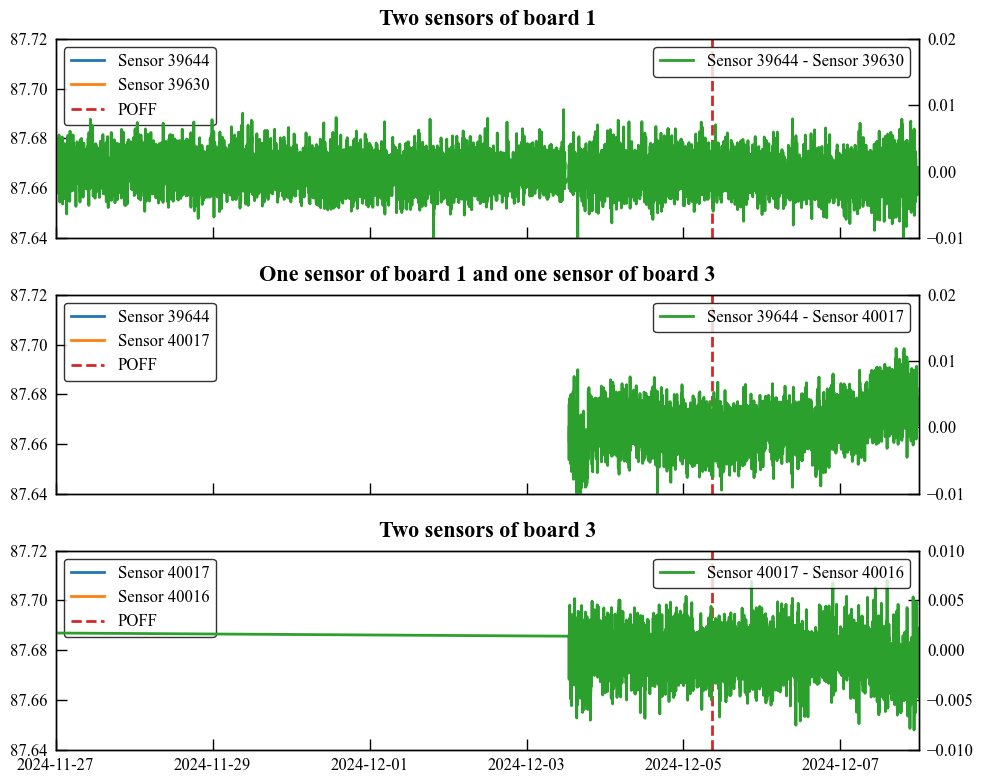

In [13]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True, sharey=True)
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39646).muxEqualization().tempCalibration(
    calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500"
    )
sensor2 = sensorClasses.Sensor(dataset=dataset, id=39644).muxEqualization().tempCalibration(
    calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500"
    )
axes[0].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 39644", color="tab:blue")
axes[0].set_xlim(pd.Timestamp("2024-11-27"), pd.Timestamp("2024-12-08"))
axes[0].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 39630", color="tab:orange")
axes[0].set_ylim(87.64, 87.72)
axes2 = axes[0].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 39644 - Sensor 39630", color="tab:green")
axes2.set_ylim(-0.01, 0.02)
axes[0].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")
axes[0].legend(loc="upper left")
axes2.legend(loc="upper right")
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39644).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
sensor2 = sensorClasses.Sensor(dataset=dataset, id=40017).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
axes[1].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 39644", color="tab:blue")
# axes[1].set_xlim(pd.Timestamp("2024-11-29"), pd.Timestamp("2024-12-06"))
axes[1].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 40017", color="tab:orange")
axes[1].set_ylim(87.64, 87.72)
axes2 = axes[1].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 39644 - Sensor 40017", color="tab:green")
axes2.set_ylim(-0.01, 0.02)
axes[1].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")
axes[1].legend(loc="upper left")
axes2.legend(loc="upper right")
sensor1 = sensorClasses.Sensor(dataset=dataset, id=40017).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
sensor2 = sensorClasses.Sensor(dataset=dataset, id=40016).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
axes[2].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 40017", color="tab:blue")
# axes[2].set_xlim(pd.Timestamp("2024-11-29"), pd.Timestamp("2024-12-06"))
axes[2].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 40016", color="tab:orange")
axes[2].set_ylim(87.64, 87.72)
axes2 = axes[2].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 40017 - Sensor 40016", color="tab:green")
axes2.set_ylim(-0.01, 0.01)
axes[2].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")

axes[0].set_title("Two sensors of board 1")
axes[1].set_title("One sensor of board 1 and one sensor of board 3")
axes[2].set_title("Two sensors of board 3")
axes[2].legend(loc="upper left")
axes2.legend(loc="upper right")
fig.tight_layout()

/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_1045/2502469716.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_1045/2502469716.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]


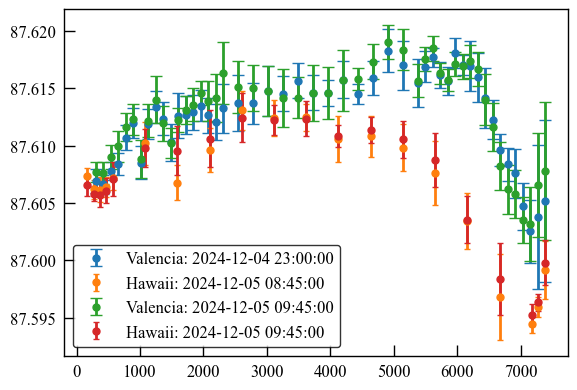

In [42]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 4, 23, 0, 0), tend=datetime.datetime(2024, 12, 4, 23, 15, 0))
profile = tgrad.profiles
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
plt.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label="Valencia: 2024-12-04 23:00:00")
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 4, 23, 0, 0), tend=datetime.datetime(2024, 12, 4, 23, 15, 0))
plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='o', label="Hawaii: 2024-12-05 08:45:00", capsize=2.5)

tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 5, 9, 45, 0), tend=datetime.datetime(2024, 12, 5, 10, 0, 0))
profile = tgrad.profiles
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
plt.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label="Valencia: 2024-12-05 09:45:00")
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 5, 9, 45, 0), tend=datetime.datetime(2024, 12, 5, 10, 0, 0))
plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='o', label="Hawaii: 2024-12-05 09:45:00", capsize=2.5)
# plt.ylim(87.6,87.625)
plt.legend()

# MUX1 and MUX4

1.0044276971442292


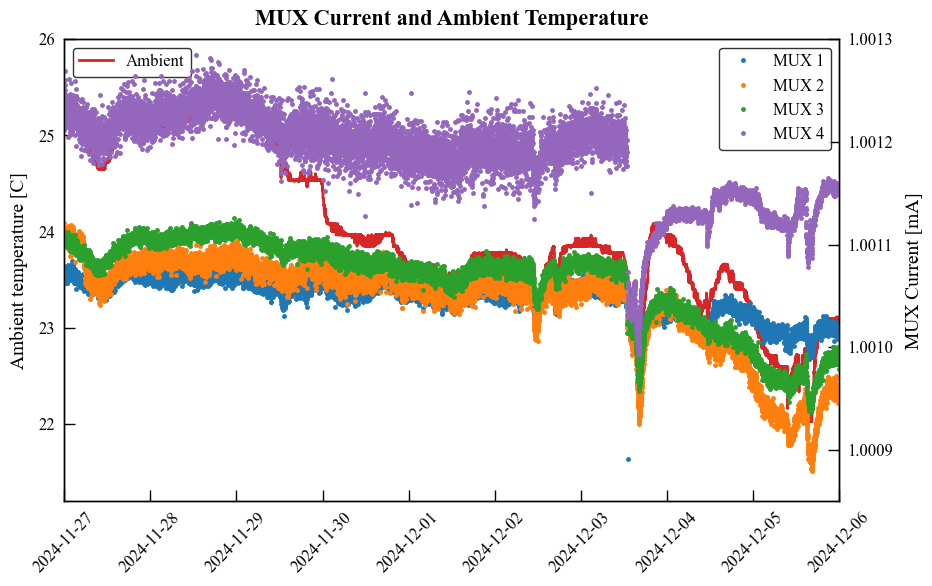

In [96]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
axes.plot(ambient.data.index.values, ambient.data.values, label="Ambient", color="tab:red")
axes.set_xlim(pd.Timestamp("2024-11-27"), pd.Timestamp("2024-12-06"))
axes.set_ylim(21.2, 26)
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
print(mux3.data.loc[(mux3.data.index > pd.Timestamp("2024-11-27")) & (mux3.data.index < pd.Timestamp("2024-12-06"))].mean())
axes2.plot(mux1.data.index.values, mux1.data.values, ".", label="MUX 1", color="tab:blue")
axes2.plot(mux2.data.index.values, mux2.data.values, ".", label="MUX 2", color="tab:orange")
axes2.plot(mux3.data.index.values, mux3.data.values + 0.0003, ".", label="MUX 3", color="tab:green")
axes2.plot(mux4.data.index.values, 4.267992590130889/(mux4.data.values) - 0.0582, ".", label="MUX 4", color="tab:purple")
axes2.set_ylim(1.00085, 1.0013)
axes.set_ylabel("Ambient temperature [C]")
axes2.set_ylabel("MUX Current [mA]")
axes.set_title("MUX Current and Ambient Temperature")
axes.legend(loc="upper left")
axes2.legend(loc="upper right")
# axes2.plot((mux1.data-mux2.data).index.values, -(mux1.data-mux2.data).values, label="MUX 1 - MUX 2", color="tab:green")
# axes2.set_ylim(-0.00015, 0.00015)

Text(0.5, 0, 'Datetime')

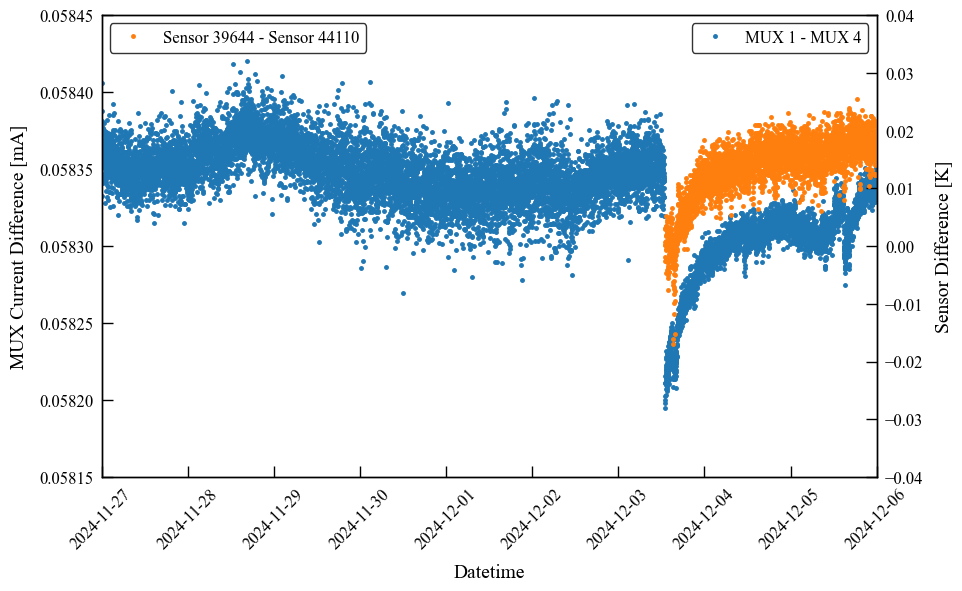

In [118]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
axes.plot(
    (mux1.data - 1/mux4.data).index.values,
    -(mux1.data - 4.267992590130889/mux4.data).values,
    ".",
    label="MUX 1 - MUX 4",
    color="tab:blue"
)
axes.set_xlim(pd.Timestamp("2024-11-27"), pd.Timestamp("2024-12-06"))
axes.set_ylim(0.05815, 0.05845)
axes.tick_params(axis='x', rotation=45)
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39644).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
sensor2 = sensorClasses.Sensor(dataset=dataset, id=44110).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
axes2 = axes.twinx()
axes2.plot(
    (sensor1.data-sensor2.data).index.values,
    (sensor1.data-sensor2.data).values,
    ".",
    label="Sensor 39644 - Sensor 44110",
    color="tab:orange"
)
axes2.set_ylim(-0.04, 0.04)
axes.legend()
axes2.legend()
axes.set_ylabel("MUX Current Difference [mA]")
axes2.set_ylabel("Sensor Difference [K]")
axes.set_xlabel("Datetime")

Text(0.5, 0, 'Datetime')

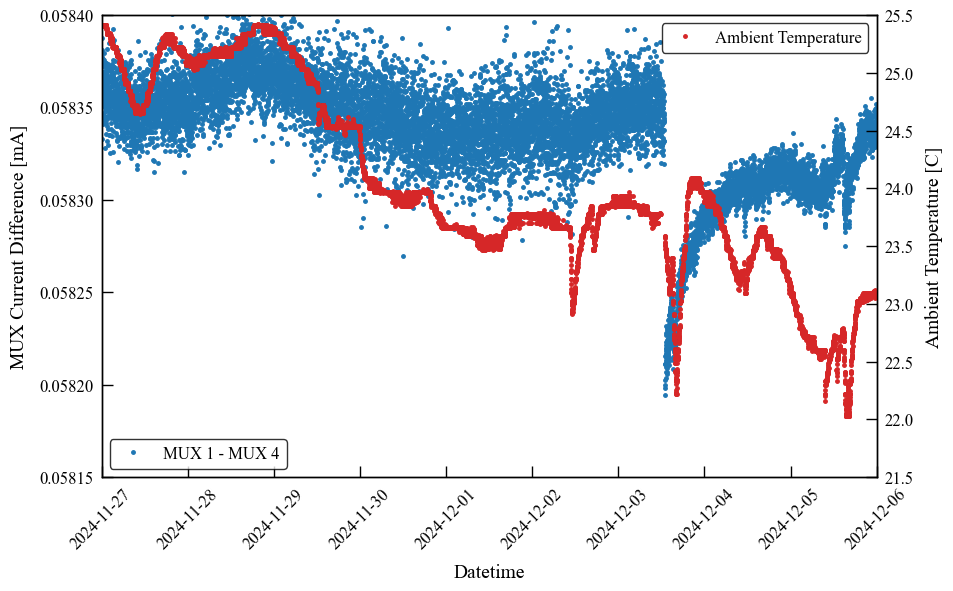

In [133]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
axes.plot(
    (mux1.data - 1/mux4.data).index.values,
    -(mux1.data - 4.267992590130889/mux4.data).values,
    ".",
    label="MUX 1 - MUX 4",
    color="tab:blue"
)
axes.set_xlim(pd.Timestamp("2024-11-27"), pd.Timestamp("2024-12-06"))
axes.set_ylim(0.05815, 0.05840)
# axes.set_xlim(pd.Timestamp("2024-12-03 12:45"))
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
axes2.plot(
    ambient.data.index.values,
    ambient.data.values,
    ".",
    label="Ambient Temperature",
    color="tab:red"
)
axes2.set_ylim(21.5, 25.5)
axes.legend(loc="lower left")
axes2.legend()
axes.set_ylabel("MUX Current Difference [mA]")
axes2.set_ylabel("Ambient Temperature [C]")
axes.set_xlabel("Datetime")

Text(0.5, 1.0, 'SWAP APA from MUX3 to MUX4')

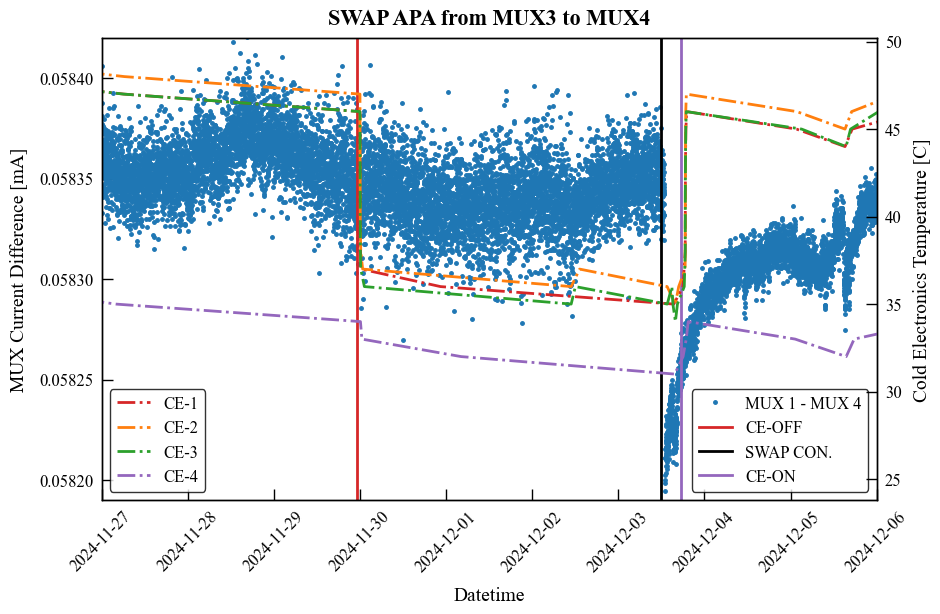

In [166]:
ce1 = sensorClasses.Sensor(dataset=dataset, id=1017)
ce2 = sensorClasses.Sensor(dataset=dataset, id=1022)
ce3 = sensorClasses.Sensor(dataset=dataset, id=1027)
ce4 = sensorClasses.Sensor(dataset=dataset, id=1032)

fig, axes = plt.subplots(1, 1, figsize=(10, 6))
axes.plot(
    (mux1.data - 1/mux4.data).index.values,
    -(mux1.data - 4.267992590130889/mux4.data).values,
    ".",
    label="MUX 1 - MUX 4",
    color="tab:blue"
)
axes.set_xlim(pd.Timestamp("2024-11-27"), pd.Timestamp("2024-12-06"))
axes.set_ylim(0.05819, 0.05842)
# axes.set_xlim(pd.Timestamp("2024-12-03 12:45"))
axes.tick_params(axis='x', rotation=45)
axes.axvline(pd.Timestamp("2024-11-29 23:15:00"), color="tab:red", linestyle="-", label="CE-OFF")
axes.axvline(pd.Timestamp("2024-12-03 12:00:00"), color="black", linestyle="-", label="SWAP CON.")
axes.axvline(pd.Timestamp("2024-12-03 17:32:00"), color="tab:purple", linestyle="-", label="CE-ON")
axes2 = axes.twinx()
axes2.plot(
    ce1.data.dropna().index.values,
    ce1.data.dropna().values,
    "-.",
    markersize=15,
    label="CE-1",
    color="tab:red"
)
axes2.plot(
    ce2.data.dropna().index.values,
    ce2.data.dropna().values,
    "-.",
    markersize=15,
    label="CE-2",
    color="tab:orange"
)
axes2.plot(
    ce3.data.dropna().index.values,
    ce3.data.dropna().values,
    "-.",
    markersize=15,
    label="CE-3",
    color="tab:green"
)
axes2.plot(
    ce4.data.dropna().index.values,
    ce4.data.dropna().values,
    "-.",
    markersize=15,
    label="CE-4",
    color="tab:purple"
)

# axes2.set_ylim(21.5, 25.5)
axes.legend(loc="lower right")
axes2.legend()
axes.set_ylabel("MUX Current Difference [mA]")
axes2.set_ylabel("Cold Electronics Temperature [C]")
axes.set_xlabel("Datetime")
axes.set_title("SWAP APA from MUX3 to MUX4")

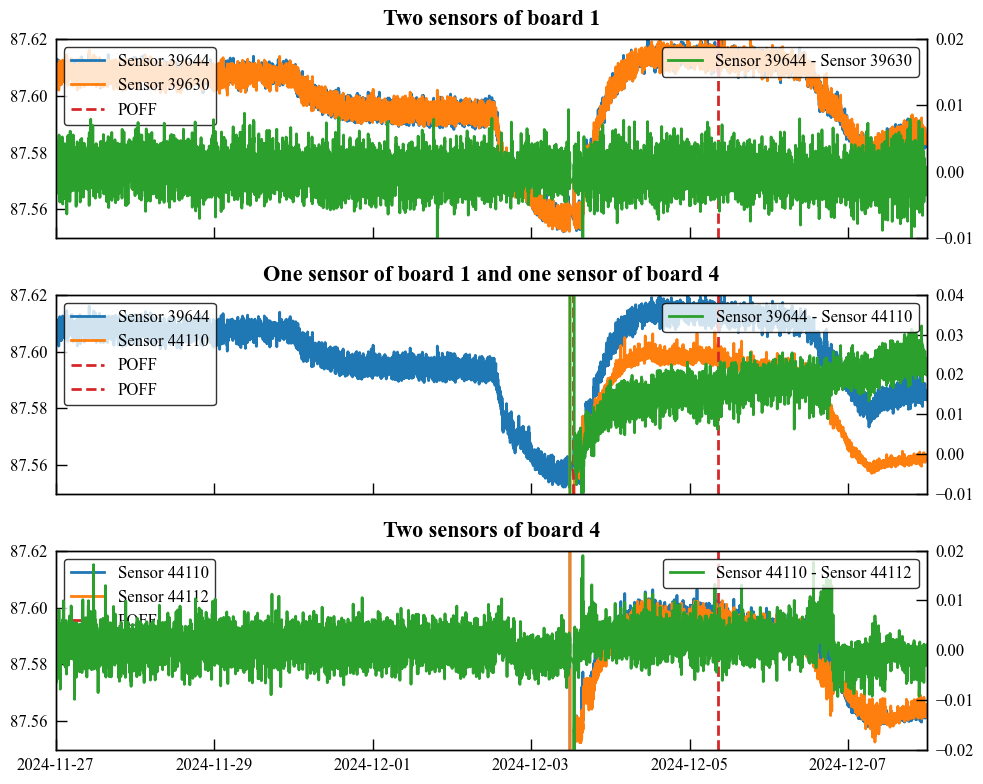

In [112]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True, sharey=True)
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39646).muxEqualization().tempCalibration(
    calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500"
    )
sensor2 = sensorClasses.Sensor(dataset=dataset, id=39644).muxEqualization().tempCalibration(
    calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500"
    )
axes[0].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 39644", color="tab:blue")
axes[0].set_xlim(pd.Timestamp("2024-11-27"), pd.Timestamp("2024-12-08"))
axes[0].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 39630", color="tab:orange")
# axes[0].set_ylim(87.64, 87.72)
axes2 = axes[0].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 39644 - Sensor 39630", color="tab:green")
axes2.set_ylim(-0.01, 0.02)
axes[0].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")
axes[0].legend(loc="upper left")
axes2.legend(loc="upper right")
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39644).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
sensor2 = sensorClasses.Sensor(dataset=dataset, id=44110).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
axes[1].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 39644", color="tab:blue")
# axes[1].set_xlim(pd.Timestamp("2024-11-29"), pd.Timestamp("2024-12-06"))
sensor2.data.loc[(sensor2.data.index < pd.Timestamp("2024-12-03 12:45:00"))] += 0.199
axes[1].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 44110", color="tab:orange")
# axes[1].set_ylim(87.64, 87.72)
axes2 = axes[1].twinx()
# sensor2.data.loc[(sensor2.data.index < pd.Timestamp("2024-12-03 12:45:00"))] += sensor2.data.loc[(sensor2.data.index > pd.Timestamp("2024-12-03 12:00:00"))&(sensor2.data.index < pd.Timestamp("2024-12-03 12:05:00"))].mean() - sensor2.data.loc[(sensor2.data.index > pd.Timestamp("2024-12-03 13:00:00"))&((sensor2.data.index < pd.Timestamp("2024-12-03 13:05:00")))].mean()

# print(sensor2.data.loc[(sensor2.data.index > pd.Timestamp("2024-12-03 12:00:00")) & (sensor2.data.index < pd.Timestamp("2024-12-03 12:05:00"))])
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 39644 - Sensor 44110", color="tab:green")
axes2.set_ylim(-0.01, 0.04)
axes[1].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")
axes[1].axvline(pd.Timestamp("2024-12-03 12:45:00"), color="tab:red", linestyle="--", label="POFF")
axes[1].legend(loc="upper left")
axes2.legend(loc="upper right")
sensor1 = sensorClasses.Sensor(dataset=dataset, id=44110).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
sensor2 = sensorClasses.Sensor(dataset=dataset, id=44112).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
axes[2].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 44110", color="tab:blue")
# axes[2].set_xlim(pd.Timestamp("2024-11-29"), pd.Timestamp("2024-12-06"))
axes[2].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 44112", color="tab:orange")
axes[2].set_ylim(87.55, 87.62)
axes2 = axes[2].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 44110 - Sensor 44112", color="tab:green")
axes2.set_ylim(-0.02, 0.02)
axes[2].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")

axes[0].set_title("Two sensors of board 1")
axes[1].set_title("One sensor of board 1 and one sensor of board 4")
axes[2].set_title("Two sensors of board 4")
axes[2].legend(loc="upper left")
axes2.legend(loc="upper right")
fig.tight_layout()

/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_1045/1782299265.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_1045/1782299265.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_1045/1782299

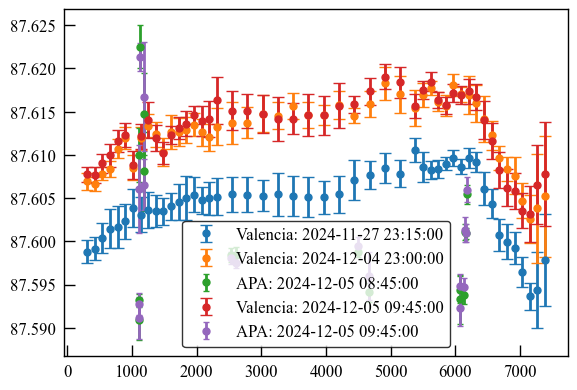

In [51]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 11, 27, 23, 0, 0), tend=datetime.datetime(2024, 11, 27, 23, 15, 0))
profile = tgrad.profiles
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
plt.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label="Valencia: 2024-11-27 23:15:00")
apa.makeProfiles(tini=datetime.datetime(2024, 11, 27, 23, 0, 0), tend=datetime.datetime(2024, 11, 27, 23, 15, 0))
# plt.errorbar(apa.profiles["Y"].values, apa.profiles["temp"].values + 0.199, yerr=apa.profiles["err"].values, fmt='o', label="APA: 2024-11-27 23:15:00", capsize=2.5)

tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 4, 23, 0, 0), tend=datetime.datetime(2024, 12, 4, 23, 15, 0))
profile = tgrad.profiles
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
plt.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label="Valencia: 2024-12-04 23:00:00")
apa.makeProfiles(tini=datetime.datetime(2024, 12, 4, 23, 0, 0), tend=datetime.datetime(2024, 12, 4, 23, 15, 0))
plt.errorbar(apa.profiles["Y"].values, apa.profiles["temp"].values, yerr=apa.profiles["err"].values, fmt='o', label="APA: 2024-12-05 08:45:00", capsize=2.5)

tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 5, 9, 45, 0), tend=datetime.datetime(2024, 12, 5, 10, 0, 0))
profile = tgrad.profiles
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
plt.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label="Valencia: 2024-12-05 09:45:00")
apa.makeProfiles(tini=datetime.datetime(2024, 12, 5, 9, 45, 0), tend=datetime.datetime(2024, 12, 5, 10, 0, 0))
plt.errorbar(apa.profiles["Y"].values, apa.profiles["temp"].values, yerr=apa.profiles["err"].values, fmt='o', label="APA: 2024-12-05 09:45:00", capsize=2.5)
plt.legend()

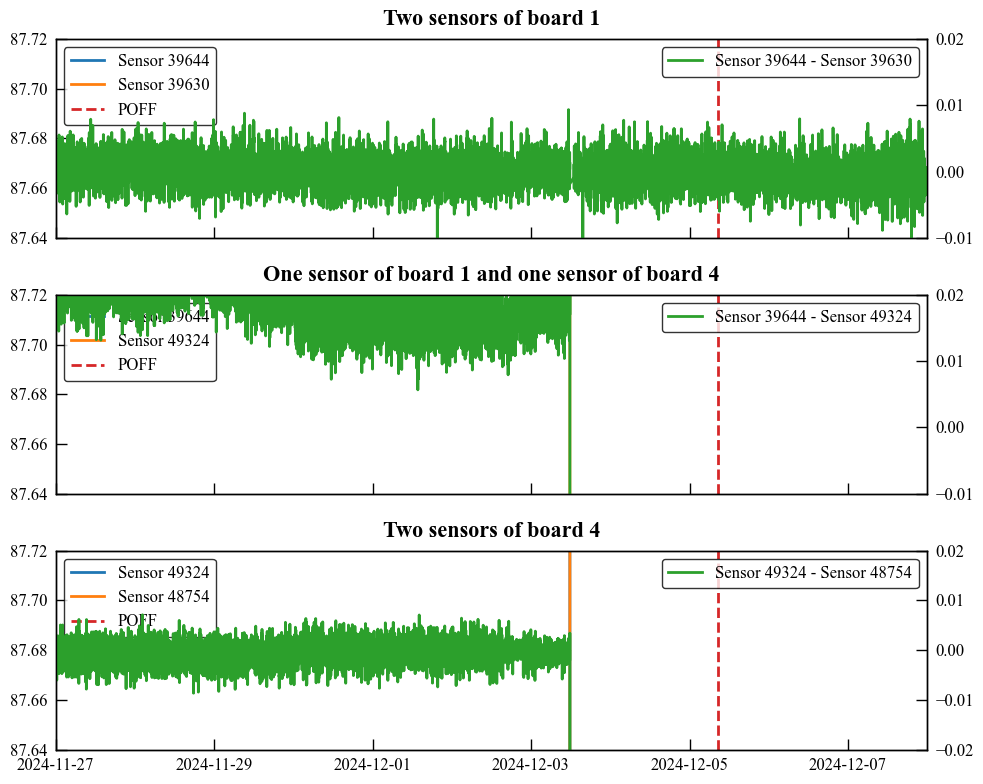

In [24]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True, sharey=True)
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39646).muxEqualization().tempCalibration(
    calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500"
    )
sensor2 = sensorClasses.Sensor(dataset=dataset, id=39644).muxEqualization().tempCalibration(
    calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500"
    )
axes[0].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 39644", color="tab:blue")
axes[0].set_xlim(pd.Timestamp("2024-11-27"), pd.Timestamp("2024-12-08"))
axes[0].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 39630", color="tab:orange")
axes[0].set_ylim(87.64, 87.72)
axes2 = axes[0].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 39644 - Sensor 39630", color="tab:green")
axes2.set_ylim(-0.01, 0.02)
axes[0].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")
axes[0].legend(loc="upper left")
axes2.legend(loc="upper right")
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39644).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
sensor2 = sensorClasses.Sensor(dataset=dataset, id=49324).muxEqualization().tempCalibration(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
axes[1].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 39644", color="tab:blue")
# axes[1].set_xlim(pd.Timestamp("2024-11-29"), pd.Timestamp("2024-12-06"))
sensor2.data -= 0.006
axes[1].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 49324", color="tab:orange")
axes[1].set_ylim(87.64, 87.72)
axes2 = axes[1].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 39644 - Sensor 49324", color="tab:green")
axes2.set_ylim(-0.01, 0.02)
axes[1].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")
axes[1].legend(loc="upper left")
axes2.legend(loc="upper right")
sensor1 = sensorClasses.Sensor(dataset=dataset, id=49324).muxEqualization().tempCalibration(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
sensor2 = sensorClasses.Sensor(dataset=dataset, id=48754).muxEqualization().tempCalibration(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
axes[2].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 49324", color="tab:blue")
# axes[2].set_xlim(pd.Timestamp("2024-11-29"), pd.Timestamp("2024-12-06"))
axes[2].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 48754", color="tab:orange")
axes[2].set_ylim(87.64, 87.72)
axes2 = axes[2].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 49324 - Sensor 48754", color="tab:green")
axes2.set_ylim(-0.02, 0.02)
axes[2].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")

axes[0].set_title("Two sensors of board 1")
axes[1].set_title("One sensor of board 1 and one sensor of board 4")
axes[2].set_title("Two sensors of board 4")
axes[2].legend(loc="upper left")
axes2.legend(loc="upper right")
fig.tight_layout()

/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_1045/3597702661.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_1045/3597702661.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]


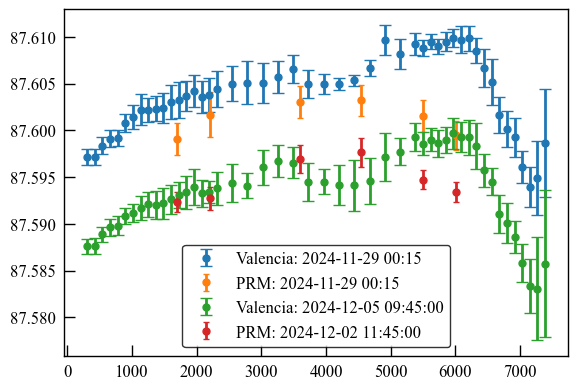

In [52]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 11, 29, 0, 0, 0), tend=datetime.datetime(2024, 11, 29, 0, 15, 0))
profile = tgrad.profiles
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
plt.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label="Valencia: 2024-11-29 00:15")
prm.makeProfiles(tini=datetime.datetime(2024, 11, 29, 0, 0, 0), tend=datetime.datetime(2024, 11, 29, 0, 15, 0))
plt.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, fmt='o', label="PRM: 2024-11-29 00:15", capsize=2.5)

tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 2, 11, 45, 0), tend=datetime.datetime(2024, 12, 2, 12, 0, 0))
profile = tgrad.profiles
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
plt.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label="Valencia: 2024-12-05 09:45:00")
prm.makeProfiles(tini=datetime.datetime(2024, 12, 2, 11, 45, 0), tend=datetime.datetime(2024, 12, 2, 12, 0, 0))
plt.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, fmt='o', label="PRM: 2024-12-02 11:45:00", capsize=2.5)
plt.legend()

[87.61100377 87.61713061]


Text(0, 0.5, 'Temperature [K]')

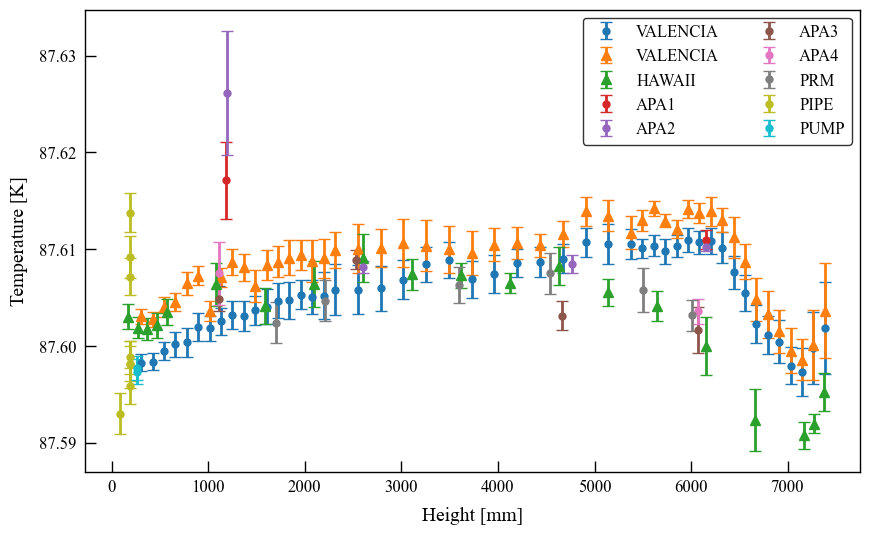

In [ ]:
plt.figure(figsize=(10, 6))
# tgrad.makeProfiles(tini=datetime.datetime(2024, 11, 27, 23, 0, 0), tend=datetime.datetime(2024, 11, 27, 23, 15, 0))
tgrad.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0, 0), tend=datetime.datetime(2024, 11, 29, 12, 30, 0))
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="VALENCIA")
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 6, 10, 0, 0), tend=datetime.datetime(2024, 12, 6, 10, 30, 0))
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='^', markersize=7.5, label="VALENCIA")
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 6, 10, 0, 0), tend=datetime.datetime(2024, 12, 6, 10, 30, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0, 0), tend=datetime.datetime(2024, 11, 29, 12, 30, 0))
pipe.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0, 0), tend=datetime.datetime(2024, 11, 29, 12, 30, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0, 0), tend=datetime.datetime(2024, 11, 29, 12, 30, 0))
pp.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0, 0), tend=datetime.datetime(2024, 11, 29, 12, 30, 0))

plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='^', markersize=7.5, label="HAWAII")
mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask5 = pipe.profiles["name"].str.contains("-", na=False) & ~pipe.profiles["name"].str.contains("I", na=False)

print(apa.profiles.loc[mask1, "temp"].values)
plt.errorbar(
    apa.profiles.loc[mask1, "Y"].values,
    apa.profiles.loc[mask1, "temp"].values,
    yerr=apa.profiles.loc[mask1, "err"].values,
    fmt='o',
    label="APA1"
)
plt.errorbar(
    apa.profiles.loc[mask2, "Y"].values,
    apa.profiles.loc[mask2, "temp"].values,
    yerr=apa.profiles.loc[mask2, "err"].values,
    fmt='o',
    label="APA2"
)
plt.errorbar(
    apa.profiles.loc[mask3, "Y"].values,
    apa.profiles.loc[mask3, "temp"].values,
    yerr=apa.profiles.loc[mask3, "err"].values,
    fmt='o',
    label="APA3"
)
plt.errorbar(
    apa.profiles.loc[mask4, "Y"].values,
    apa.profiles.loc[mask4, "temp"].values,
    yerr=apa.profiles.loc[mask4, "err"].values,
    fmt='o',
    label="APA4"
)
plt.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, fmt='o', label="PRM")
plt.errorbar(
    pipe.profiles.loc[mask5, "Y"].values,
    pipe.profiles.loc[mask5, "temp"].values,
    yerr=pipe.profiles.loc[mask5, "err"].values,
    fmt='o', label="PIPE"
    )
plt.errorbar(pp.profiles["Y"].values, pp.profiles["temp"].values, yerr=pp.profiles["err"].values, fmt='o', label="PUMP")
# plt.ylim(87.675, 87.725)
plt.legend(ncol=2);
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")

[87.60276084 87.61060533]


Text(0, 0.5, 'Temperature [K]')

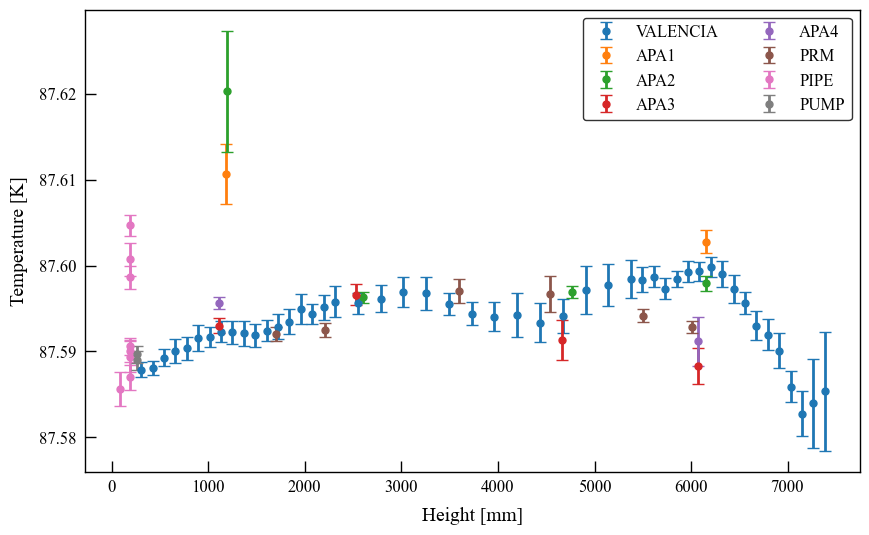

In [7]:
plt.figure(figsize=(10, 6))
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 2, 11, 30, 0), tend=datetime.datetime(2024, 12, 2, 11, 45, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 4, 23, 0, 0), tend=datetime.datetime(2024, 12, 4, 23, 15, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 12, 2, 11, 30, 0), tend=datetime.datetime(2024, 12, 2, 11, 45, 0))
pipe.makeProfiles(tini=datetime.datetime(2024, 12, 2, 11, 30, 0), tend=datetime.datetime(2024, 12, 2, 11, 45, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 12, 2, 11, 30, 0), tend=datetime.datetime(2024, 12, 2, 11, 45, 0))
pp.makeProfiles(tini=datetime.datetime(2024, 12, 2, 11, 30, 0), tend=datetime.datetime(2024, 12, 2, 11, 45, 0))
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="VALENCIA")
# plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='o', label="HAWAII")
mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask5 = pipe.profiles["name"].str.contains("-", na=False) & ~pipe.profiles["name"].str.contains("I", na=False)

print(apa.profiles.loc[mask1, "temp"].values)
plt.errorbar(
    apa.profiles.loc[mask1, "Y"].values,
    apa.profiles.loc[mask1, "temp"].values,
    yerr=apa.profiles.loc[mask1, "err"].values,
    fmt='o',
    label="APA1"
)
plt.errorbar(
    apa.profiles.loc[mask2, "Y"].values,
    apa.profiles.loc[mask2, "temp"].values,
    yerr=apa.profiles.loc[mask2, "err"].values,
    fmt='o',
    label="APA2"
)
plt.errorbar(
    apa.profiles.loc[mask3, "Y"].values,
    apa.profiles.loc[mask3, "temp"].values,
    yerr=apa.profiles.loc[mask3, "err"].values,
    fmt='o',
    label="APA3"
)
plt.errorbar(
    apa.profiles.loc[mask4, "Y"].values,
    apa.profiles.loc[mask4, "temp"].values,
    yerr=apa.profiles.loc[mask4, "err"].values,
    fmt='o',
    label="APA4"
)
plt.errorbar(
    prm.profiles["Y"].values,
    prm.profiles["temp"].values,
    yerr=prm.profiles["err"].values,
    fmt='o', label="PRM"
    )
plt.errorbar(
    pipe.profiles.loc[mask5, "Y"].values,
    pipe.profiles.loc[mask5, "temp"].values,
    yerr=pipe.profiles.loc[mask5, "err"].values,
    fmt='o', label="PIPE"
    )
plt.errorbar(
    pp.profiles["Y"].values,
    pp.profiles["temp"].values,
    yerr=pp.profiles["err"].values,
    fmt='o', label="PUMP"
    )

# plt.ylim(87.675, 87.725)
plt.legend(ncol=2);
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")

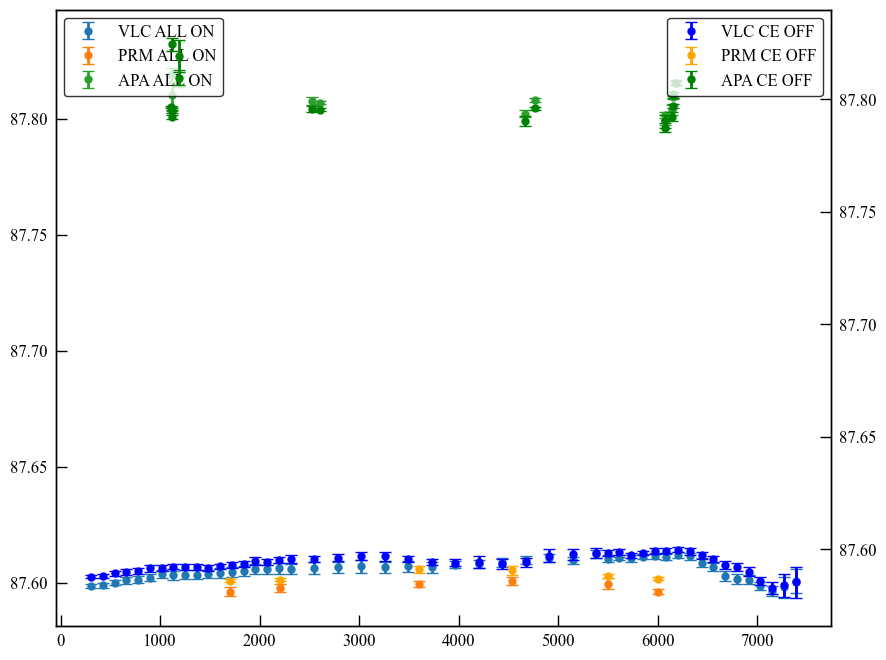

In [8]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 8), sharex=True, sharey=True)
tgrad.makeProfiles(tini=datetime.datetime(2024, 11, 27, 23, 0, 0), tend=datetime.datetime(2024, 11, 27, 23, 55, 0))
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', color="tab:blue", label="VLC ALL ON")
prm.makeProfiles(tini=datetime.datetime(2024, 11, 27, 23, 0, 0), tend=datetime.datetime(2024, 11, 27, 23, 55, 0))
axes.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values - 0.006, yerr=prm.profiles["err"].values, fmt='o', color="tab:orange", label="PRM ALL ON")
apa.makeProfiles(tini=datetime.datetime(2024, 11, 27, 23, 0, 0), tend=datetime.datetime(2024, 11, 27, 23, 15, 0))
axes.errorbar(apa.profiles["Y"].values, apa.profiles["temp"].values + 0.199, yerr=apa.profiles["err"].values, fmt='o', color="tab:green", label="APA ALL ON")
axes2 = axes.twinx()
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 2, 11, 30, 0), tend=datetime.datetime(2024, 12, 2, 11, 45, 0))
axes2.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', color="blue", label="VLC CE OFF")
prm.makeProfiles(tini=datetime.datetime(2024, 12, 2, 11, 30, 0), tend=datetime.datetime(2024, 12, 2, 11, 45, 0))
axes2.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values - 0.006, yerr=prm.profiles["err"].values, fmt='o', color="orange", label="PRM CE OFF")
apa.makeProfiles(tini=datetime.datetime(2024, 12, 2, 11, 30, 0), tend=datetime.datetime(2024, 12, 2, 11, 45, 0))
axes2.errorbar(apa.profiles["Y"].values, apa.profiles["temp"].values + 0.199, yerr=apa.profiles["err"].values, fmt='o', color="green", label="APA CE OFF")
axes.legend(loc="upper left")
axes2.legend(loc="upper right")

# FIRST PUMPS-OFF PERIOD

## MUX1 and MUX2

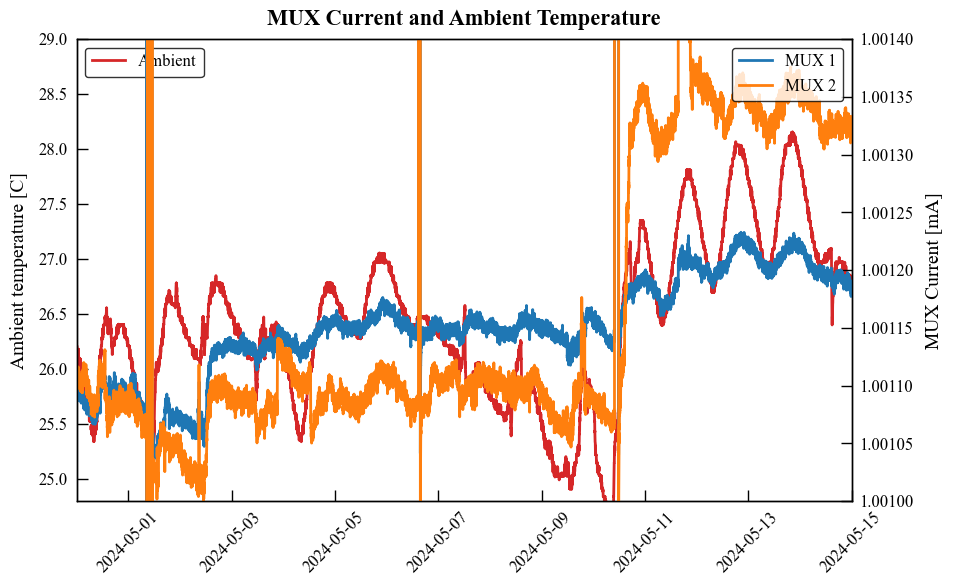

In [55]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
axes.plot(ambient.data.index.values, ambient.data.values, label="Ambient", color="tab:red")
axes.set_xlim(pd.Timestamp("2024-4-30"), pd.Timestamp("2024-5-15"))
axes.set_ylim(24.8, 29)
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
axes2.plot(mux1.data.index.values, mux1.data.values, label="MUX 1", color="tab:blue")
axes2.plot(mux2.data.index.values, mux2.data.values, label="MUX 2", color="tab:orange")
axes2.set_ylim(1.001, 1.0014)
axes.set_ylabel("Ambient temperature [C]")
axes2.set_ylabel("MUX Current [mA]")
axes.set_title("MUX Current and Ambient Temperature")
axes.legend(loc="upper left")
axes2.legend(loc="upper right")
# axes2.plot((mux1.data-mux2.data).index.values, -(mux1.data-mux2.data).values, label="MUX 1 - MUX 2", color="tab:green")
# axes2.set_ylim(-0.00015, 0.00015)

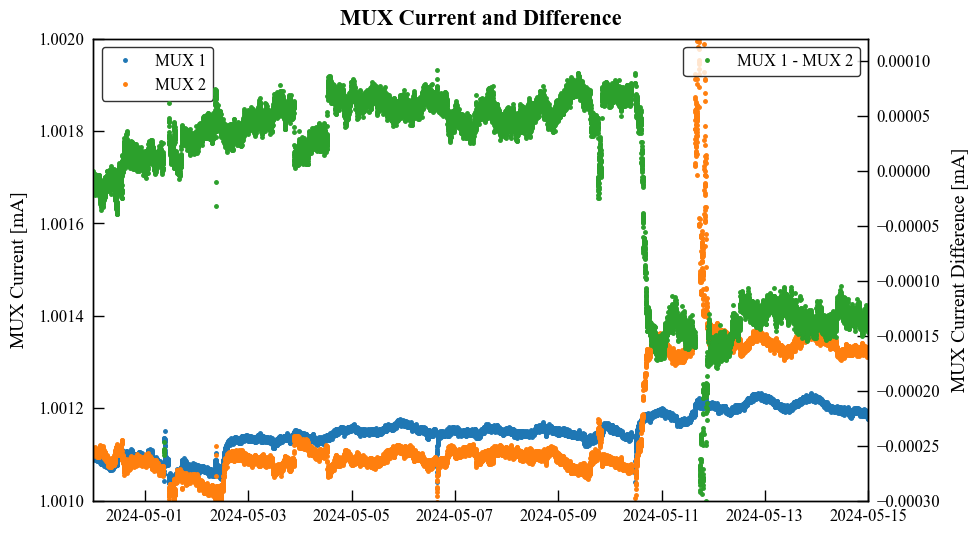

In [64]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
axes.plot(mux1.data.index.values, mux1.data.values, ".", label="MUX 1", color="tab:blue")
axes.set_xlim(pd.Timestamp("2024-4-30"), pd.Timestamp("2024-5-15"))
axes.plot(mux2.data.index.values, mux2.data.values, ".", label="MUX 2", color="tab:orange")
axes2 = axes.twinx()
axes2.plot((mux1.data-mux2.data).index.values, (mux1.data-mux2.data).values, ".", label="MUX 1 - MUX 2", color="tab:green")
axes.set_ylim(1.001, 1.0020)
axes2.set_ylim(-0.0003, 0.00012)
axes.set_ylabel("MUX Current [mA]")
axes2.set_ylabel("MUX Current Difference [mA]")
axes.set_title("MUX Current and Difference")
axes.legend(loc="upper left")
axes2.legend(loc="upper right")

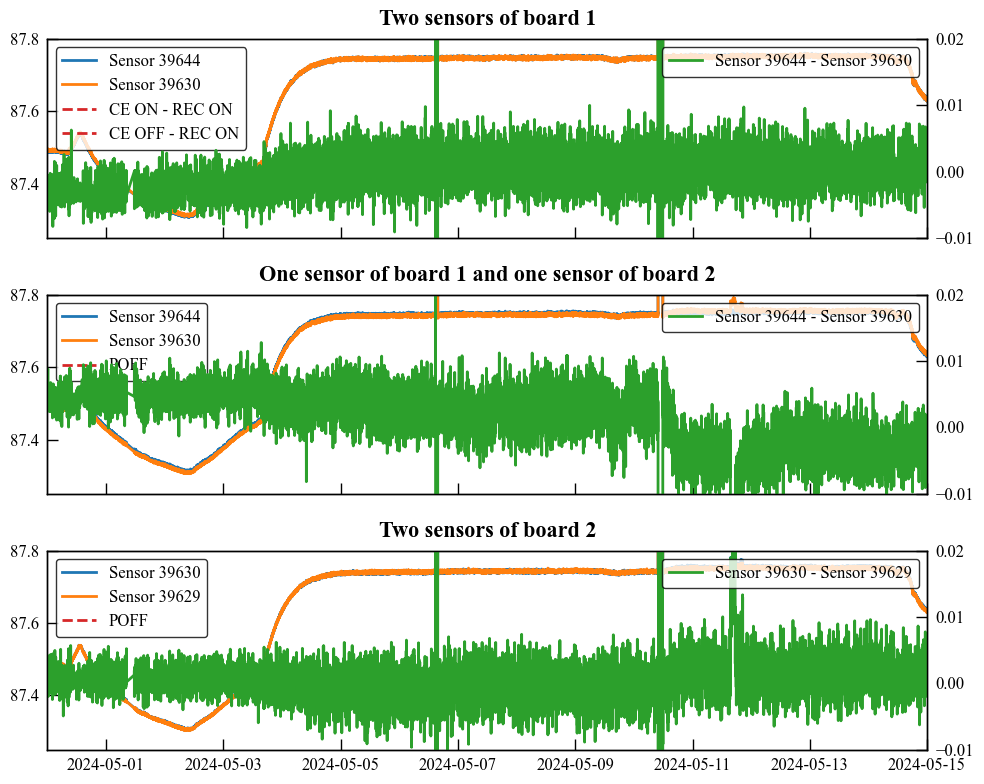

In [70]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True, sharey=True)
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39646).muxEqualization().tempCalibration(
    calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500"
    )
sensor2 = sensorClasses.Sensor(dataset=dataset, id=39644).muxEqualization().tempCalibration(
    calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500"
    )
axes[0].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 39644", color="tab:blue")
axes[0].set_xlim(pd.Timestamp("2024-4-30"), pd.Timestamp("2024-5-15"))
axes[0].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 39630", color="tab:orange")
axes[0].set_ylim(87.64, 87.72)
axes2 = axes[0].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 39644 - Sensor 39630", color="tab:green")
axes2.set_ylim(-0.01, 0.02)
axes[0].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="CE ON - REC ON")
axes[0].axvline(pd.Timestamp("2024-12-02 11:45:00"), color="tab:red", linestyle="--", label="CE OFF - REC ON")
axes[0].legend(loc="upper left")
axes2.legend(loc="upper right")
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39644).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
sensor2 = sensorClasses.Sensor(dataset=dataset, id=39630).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
axes[1].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 39644", color="tab:blue")
# axes[1].set_xlim(pd.Timestamp("2024-11-29"), pd.Timestamp("2024-12-06"))
sensor2.data.loc[(sensor2.data.index > pd.Timestamp("2024-5-01 12:45:00"))] += 0.002
axes[1].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 39630", color="tab:orange")
axes[1].set_ylim(87.64, 87.72)
axes2 = axes[1].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 39644 - Sensor 39630", color="tab:green")
axes2.set_ylim(-0.01, 0.02)
axes[1].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")
axes[1].legend(loc="upper left")
axes2.legend(loc="upper right")
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39630).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
sensor2 = sensorClasses.Sensor(dataset=dataset, id=39629).muxEqualization().tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
axes[2].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 39630", color="tab:blue")
# axes[2].set_xlim(pd.Timestamp("2024-11-29"), pd.Timestamp("2024-12-06"))
axes[2].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 39629", color="tab:orange")
axes[2].set_ylim(87.25, 87.8)
axes2 = axes[2].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 39630 - Sensor 39629", color="tab:green")
axes2.set_ylim(-0.01, 0.02)
axes[2].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")

axes[0].set_title("Two sensors of board 1")
axes[1].set_title("One sensor of board 1 and one sensor of board 2")
axes[2].set_title("Two sensors of board 2")
axes[2].legend(loc="upper left")
axes2.legend(loc="upper right")
fig.tight_layout()

Text(0, 0.5, 'Temperature [K] - T(305mm)')

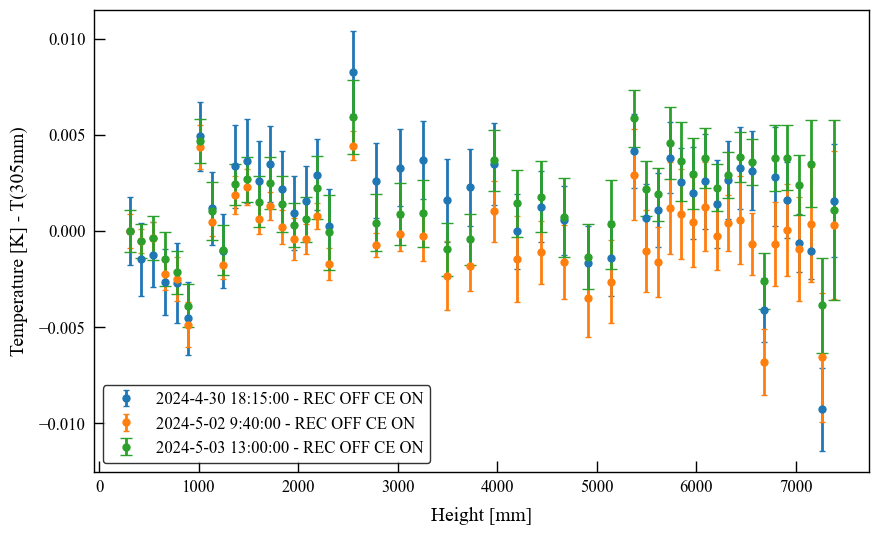

In [85]:
plt.figure(figsize=(10, 6))
tgrad.makeProfiles(tini=datetime.datetime(2024, 4, 30, 18, 15, 0), tend=datetime.datetime(2024, 4, 30, 18, 45, 0))
profile = tgrad.profiles
profile.loc[(profile["Y"]>3960), "temp"] -= 0.0035
plt.errorbar(profile["Y"].values, profile["temp"].values - profile["temp"].loc[(profile["Y"]==305)].values[0], yerr=profile["err"].values, fmt='o', capsize=2.5, label="2024-4-30 18:15:00 - REC OFF CE ON")
# tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 1, 0, 0, 0), tend=datetime.datetime(2024, 5, 1, 0, 30, 0))
# profile = tgrad.profiles
# profile.loc[(profile["Y"]>3960), "temp"] -= 0.0035
# plt.errorbar(profile["Y"].values, profile["temp"].values - profile["temp"].loc[(profile["Y"]==305)].values[0], yerr=profile["err"].values, fmt='o', label="2024-5-01 00:00:00")
# tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 1, 1, 0, 0), tend=datetime.datetime(2024, 12, 1, 1, 15, 0))
# plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0], yerr=tgrad.profiles["err"].values, fmt='o', label="2024-12-11 01:00:00")
tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 40, 0), tend=datetime.datetime(2024, 5, 2, 10, 00, 0))
profile = tgrad.profiles
profile.loc[(profile["Y"]>3960), "temp"] -= 0.0035
plt.errorbar(profile["Y"].values, profile["temp"].values - profile["temp"].loc[(profile["Y"]==305)].values[0], yerr=profile["err"].values, fmt='o', capsize=2.5, label="2024-5-02 9:40:00 - REC OFF CE ON")
# tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 4, 0, 0, 0), tend=datetime.datetime(2024, 12, 4, 0, 15, 0))
# plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0], yerr=tgrad.profiles["err"].values, fmt='o', label="2024-12-04 08:45:00")
# tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 5, 0, 0, 0), tend=datetime.datetime(2024, 12, 5, 0, 15, 0))
# plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"]==305)].values[0], yerr=tgrad.profiles["err"].values, fmt='o', label="2024-12-05 00:00:00")
tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 3, 13, 0, 0), tend=datetime.datetime(2024, 5, 3, 13, 30, 0))
profile = tgrad.profiles
profile.loc[(profile["Y"]>3960), "temp"] -= 0.0035
plt.errorbar(profile["Y"].values, profile["temp"].values - profile["temp"].loc[(profile["Y"]==305)].values[0], yerr=profile["err"].values, fmt='o', label="2024-5-03 13:00:00 - REC OFF CE ON")

# tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 6, 0, 0, 0), tend=datetime.datetime(2024, 5, 6, 0, 45, 0))
# profile = tgrad.profiles
# profile.loc[(profile["Y"]>3960), "temp"] -= 0.0035
# plt.errorbar(profile["Y"].values, profile["temp"].values - profile["temp"].loc[(profile["Y"]==305)].values[0], yerr=profile["err"].values, fmt='o', label="2024-5-06 00:00:00")
plt.legend()
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K] - T(305mm)")

## MUX 1 and MUX3

1.1142963981257514


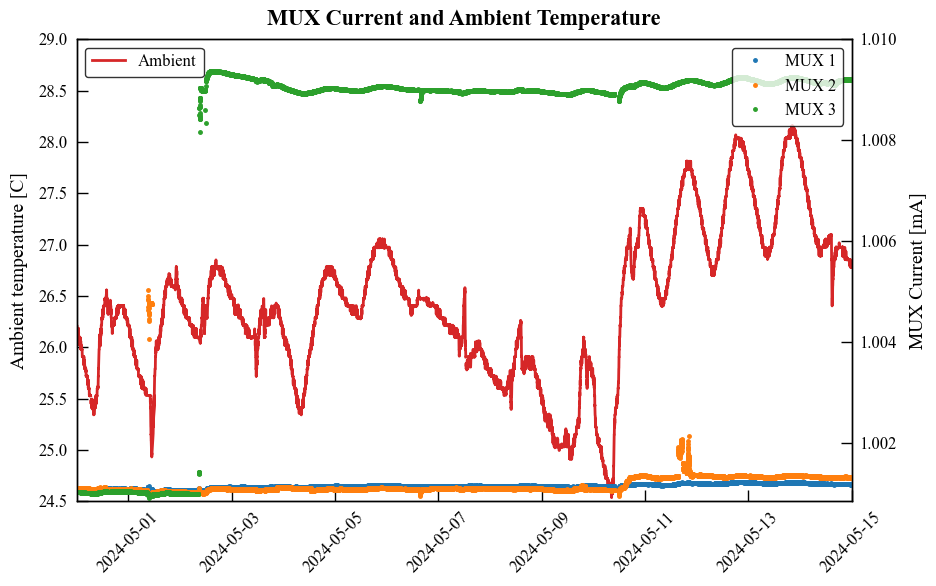

In [88]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
axes.plot(ambient.data.index.values, ambient.data.values, label="Ambient", color="tab:red")
axes.set_xlim(pd.Timestamp("2024-4-30"), pd.Timestamp("2024-5-15"))
axes.set_ylim(24.5, 29)
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
print(mux3.data.loc[(mux3.data.index > pd.Timestamp("2024-4-30")) & (mux3.data.index < pd.Timestamp("2024-5-15"))].mean())
axes2.plot(mux1.data.index.values, mux1.data.values, ".", label="MUX 1", color="tab:blue")
axes2.plot(mux2.data.index.values, mux2.data.values, ".", label="MUX 2", color="tab:orange")
axes2.plot(mux3.data.index.values, mux3.data.values + 0.0003, ".", label="MUX 3", color="tab:green")
# axes2.set_ylim(1.00085, 1.0012)
axes2.set_ylim(1.00085, 1.01)
axes.set_ylabel("Ambient temperature [C]")
axes2.set_ylabel("MUX Current [mA]")
axes.set_title("MUX Current and Ambient Temperature")
axes.legend(loc="upper left")
axes2.legend(loc="upper right")
# axes2.plot((mux1.data-mux2.data).index.values, -(mux1.data-mux2.data).values, label="MUX 1 - MUX 2", color="tab:green")
# axes2.set_ylim(-0.00015, 0.00015)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


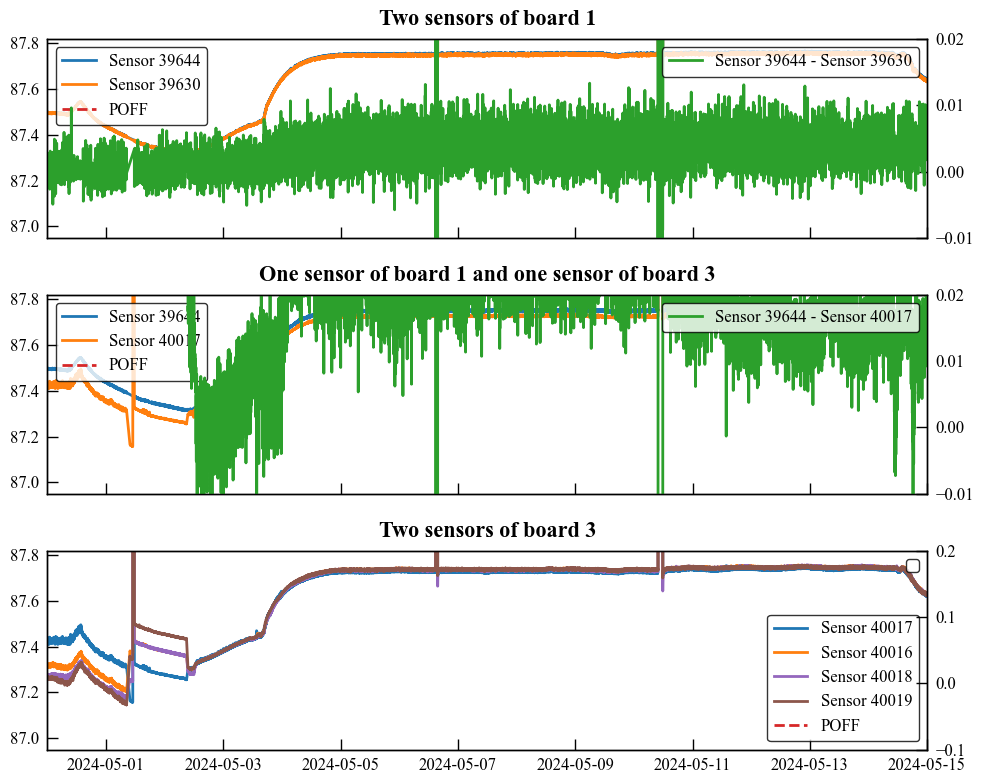

In [102]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True, sharey=True)
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39646).muxEqualization().tempCalibration(
    calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000"
    )
sensor2 = sensorClasses.Sensor(dataset=dataset, id=39644).muxEqualization().tempCalibration(
    calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000"
    )
axes[0].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 39644", color="tab:blue")
axes[0].set_xlim(pd.Timestamp("2024-4-30"), pd.Timestamp("2024-5-15"))
axes[0].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 39630", color="tab:orange")
axes[0].set_ylim(87.64, 87.72)
axes2 = axes[0].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 39644 - Sensor 39630", color="tab:green")
axes2.set_ylim(-0.01, 0.02)
axes[0].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")
axes[0].legend(loc="upper left")
axes2.legend(loc="upper right")
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39644).muxEqualization().tempCalibration(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000")
sensor2 = sensorClasses.Sensor(dataset=dataset, id=44110).muxEqualization().tempCalibration(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000")
axes[1].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 39644", color="tab:blue")
# axes[1].set_xlim(pd.Timestamp("2024-11-29"), pd.Timestamp("2024-12-06"))
axes[1].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 40017", color="tab:orange")
axes[1].set_ylim(87.64, 87.72)
axes2 = axes[1].twinx()
axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 39644 - Sensor 40017", color="tab:green")
axes2.set_ylim(-0.01, 0.02)
axes[1].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")
axes[1].legend(loc="upper left")
axes2.legend(loc="upper right")
sensor1 = sensorClasses.Sensor(dataset=dataset, id=44110).muxEqualization().tempCalibration(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000")
sensor2 = sensorClasses.Sensor(dataset=dataset, id=44111).muxEqualization().tempCalibration(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000")
sensor3 = sensorClasses.Sensor(dataset=dataset, id=44112).muxEqualization().tempCalibration(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000")
sensor4 = sensorClasses.Sensor(dataset=dataset, id=44113).muxEqualization().tempCalibration(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000")
axes[2].plot(sensor1.data.index.values, sensor1.data.values, label="Sensor 40017", color="tab:blue")
# axes[2].set_xlim(pd.Timestamp("2024-11-29"), pd.Timestamp("2024-12-06"))
axes[2].plot(sensor2.data.index.values, sensor2.data.values, label="Sensor 40016", color="tab:orange")
axes[2].plot(sensor3.data.index.values, sensor3.data.values, label="Sensor 40018", color="tab:purple")
axes[2].plot(sensor4.data.index.values, sensor4.data.values, label="Sensor 40019", color="tab:brown")
axes[2].set_ylim(86.95, 87.82);
axes2 = axes[2].twinx()
# axes2.plot((sensor1.data-sensor2.data).index.values, (sensor1.data-sensor2.data).values, label="Sensor 40017 - Sensor 40016", color="tab:green")
axes2.set_ylim(-0.1, 0.2)
axes[2].axvline(pd.Timestamp("2024-12-05 8:45:00"), color="tab:red", linestyle="--", label="POFF")

axes[0].set_title("Two sensors of board 1")
axes[1].set_title("One sensor of board 1 and one sensor of board 3")
axes[2].set_title("Two sensors of board 3")
axes[2].legend(loc="lower right")
axes2.legend(loc="upper right")
fig.tight_layout()

In [27]:
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
apa.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000")
prm.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000")
pipe.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000")
pp.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:06<00:00,  7.97sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:00<00:00, 113.16sensor/s]
Equalizing APA Sensors:  12%|█▎        | 2/16 [00:00<00:00, 14.62sensor/s]

ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found i

Equalizing APA Sensors:  25%|██▌       | 4/16 [00:00<00:00, 12.44sensor/s]

ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found i

Equalizing APA Sensors:  38%|███▊      | 6/16 [00:00<00:01,  9.69sensor/s]

...

Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:02<00:00,  5.68sensor/s]


ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Channel (TE0120) not found
ERROR: Board (11.0) not found in equalization (LAST_SUM)


Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000: 100%|██████████| 12/12 [00:00<00:00, 60.52sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00,  8.32sensor/s]


ERROR: Board (11.0) not found in equalization (LAST_SUM)
ERROR: Board (11.0) not found in equalization (LAST_SUM)


Calibrating PP Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000: 100%|██████████| 2/2 [00:00<00:00, 84.33sensor/s]


Text(0, 0.5, 'Temperature [K] - T(305mm)')

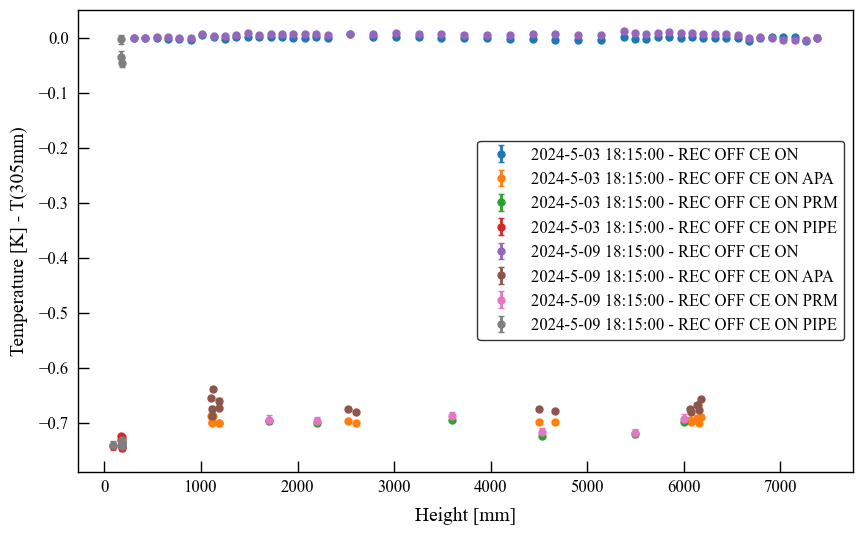

In [29]:
plt.figure(figsize=(10, 6))
tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 3, 6, 15, 0), tend=datetime.datetime(2024, 5, 3, 6, 45, 0))
profile = tgrad.profiles
profile.loc[(profile["Y"]>3960), "temp"] -= 0.0035
plt.errorbar(profile["Y"].values, profile["temp"].values - profile.loc[(profile["Y"]==305)]["temp"].values[0], yerr=profile["err"].values, fmt='o', capsize=2.5, label="2024-5-03 18:15:00 - REC OFF CE ON")
apa.makeProfiles(tini=datetime.datetime(2024, 5, 3, 6, 15, 0), tend=datetime.datetime(2024, 5, 3, 6, 45, 0))
profile = apa.profiles
plt.errorbar(profile["Y"].values, profile["temp"].values - tgrad.profiles.loc[(tgrad.profiles["Y"]==305)]["temp"].values[0], yerr=profile["err"].values, fmt='o', capsize=2.5, label="2024-5-03 18:15:00 - REC OFF CE ON APA")
prm.makeProfiles(tini=datetime.datetime(2024, 5, 3, 6, 15, 0), tend=datetime.datetime(2024, 5, 3, 6, 45, 0))
profile = prm.profiles
plt.errorbar(profile["Y"].values, profile["temp"].values - tgrad.profiles.loc[(tgrad.profiles["Y"]==305)]["temp"].values[0] - 0.006, yerr=profile["err"].values, fmt='o', capsize=2.5, label="2024-5-03 18:15:00 - REC OFF CE ON PRM")
pipe.makeProfiles(tini=datetime.datetime(2024, 5, 3, 6, 15, 0), tend=datetime.datetime(2024, 5, 3, 6, 45, 0))
profile = pipe.profiles
plt.errorbar(profile["Y"].values, profile["temp"].values - tgrad.profiles.loc[(tgrad.profiles["Y"]==305)]["temp"].values[0] - 0.006, yerr=profile["err"].values, fmt='o', capsize=2.5, label="2024-5-03 18:15:00 - REC OFF CE ON PIPE")
tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 9, 18, 15, 0), tend=datetime.datetime(2024, 5, 9, 18, 45, 0))
profile = tgrad.profiles
profile.loc[(profile["Y"]>3960), "temp"] -= 0.0035
plt.errorbar(profile["Y"].values, profile["temp"].values - profile.loc[(profile["Y"]==305)]["temp"].values[0], yerr=profile["err"].values, fmt='o', capsize=2.5, label="2024-5-09 18:15:00 - REC OFF CE ON")
apa.makeProfiles(tini=datetime.datetime(2024, 5, 9, 18, 15, 0), tend=datetime.datetime(2024, 5, 9, 18, 45, 0))
profile = apa.profiles
plt.errorbar(profile["Y"].values, profile["temp"].values - tgrad.profiles.loc[(tgrad.profiles["Y"]==305)]["temp"].values[0], yerr=profile["err"].values, fmt='o', capsize=2.5, label="2024-5-09 18:15:00 - REC OFF CE ON APA")
prm.makeProfiles(tini=datetime.datetime(2024, 5, 9, 18, 15, 0), tend=datetime.datetime(2024, 5, 9, 18, 45, 0))
profile = prm.profiles
plt.errorbar(profile["Y"].values, profile["temp"].values - tgrad.profiles.loc[(tgrad.profiles["Y"]==305)]["temp"].values[0] - 0.006, yerr=profile["err"].values, fmt='o', capsize=2.5, label="2024-5-09 18:15:00 - REC OFF CE ON PRM")
pipe.makeProfiles(tini=datetime.datetime(2024, 5, 9, 18, 15, 0), tend=datetime.datetime(2024, 5, 9, 18, 45, 0))
profile = pipe.profiles
plt.errorbar(profile["Y"].values, profile["temp"].values - tgrad.profiles.loc[(tgrad.profiles["Y"]==305)]["temp"].values[0] - 0.006, yerr=profile["err"].values, fmt='o', capsize=2.5, label="2024-5-09 18:15:00 - REC OFF CE ON PIPE")
# plt.ylim(-0.015, 0.035)
plt.legend()
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K] - T(305mm)")

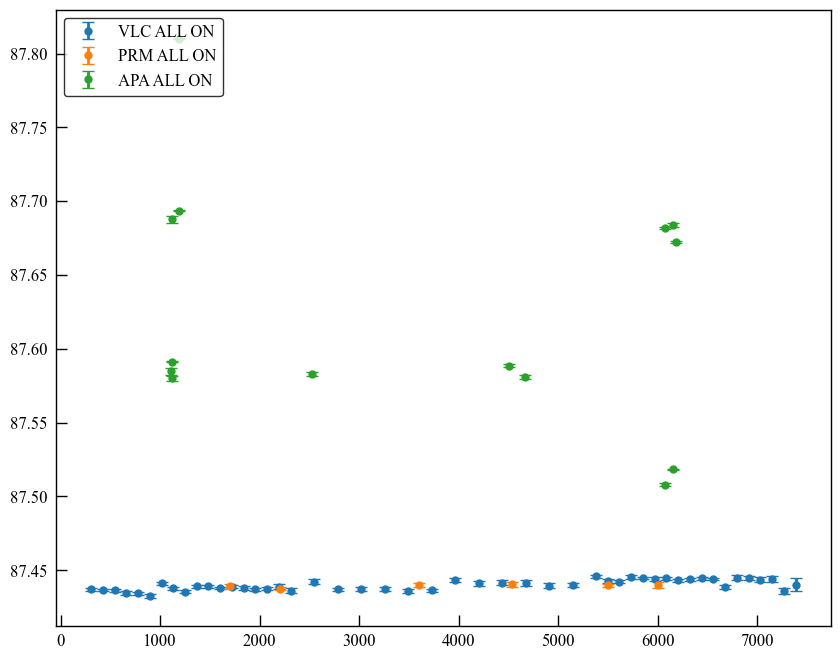

In [49]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 8), sharex=True, sharey=True)
tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 3, 12, 50, 0), tend=datetime.datetime(2024, 5, 3, 13, 10, 0))
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', color="tab:blue", label="VLC ALL ON")
prm.makeProfiles(tini=datetime.datetime(2024, 5, 3, 12, 50, 0), tend=datetime.datetime(2024, 5, 3, 13, 10, 0))
axes.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values - 0.006, yerr=prm.profiles["err"].values, fmt='o', color="tab:orange", label="PRM ALL ON")
apa.makeProfiles(tini=datetime.datetime(2024, 5, 3, 12, 50, 0), tend=datetime.datetime(2024, 5, 3, 13, 10, 0))
axes.errorbar(apa.profiles["Y"].values, apa.profiles["temp"].values + 0.199, yerr=apa.profiles["err"].values, fmt='o', color="tab:green", label="APA ALL ON")
# axes2 = axes.twinx()
# tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 2, 11, 30, 0), tend=datetime.datetime(2024, 12, 2, 11, 45, 0))
# axes2.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', color="blue", label="VLC CE OFF")
# prm.makeProfiles(tini=datetime.datetime(2024, 12, 2, 11, 30, 0), tend=datetime.datetime(2024, 12, 2, 11, 45, 0))
# axes2.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values - 0.006, yerr=prm.profiles["err"].values, fmt='o', color="orange", label="PRM CE OFF")
# apa.makeProfiles(tini=datetime.datetime(2024, 12, 2, 11, 30, 0), tend=datetime.datetime(2024, 12, 2, 11, 45, 0))
# axes2.errorbar(apa.profiles["Y"].values, apa.profiles["temp"].values + 0.199, yerr=apa.profiles["err"].values, fmt='o', color="green", label="APA CE OFF")
axes.legend(loc="upper left")
# axes2.legend(loc="upper right")

[nan nan]


/Users/jcapo/opt/anaconda3/envs/my_root_env/lib/python3.10/site-packages/matplotlib/axes/_base.py:2480: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


Text(0, 0.5, 'Temperature [K]')

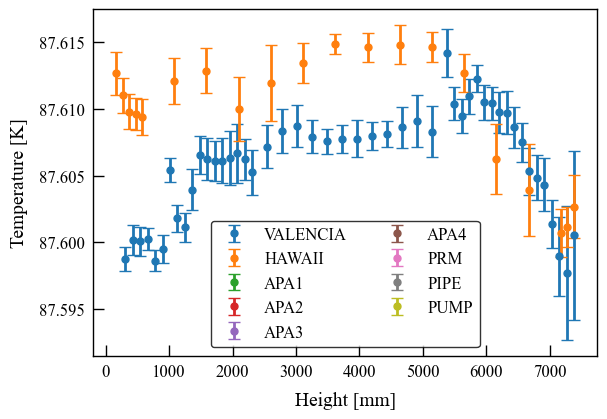

In [18]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
# apa.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 45, 0), tend=datetime.datetime(2024, 12, 2, 6, 0, 0))
pipe.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
pp.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="VALENCIA")
plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='o', label="HAWAII")
mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask5 = pipe.profiles["name"].str.contains("-", na=False) & ~apa.profiles["name"].str.contains("I", na=False)

plt.errorbar(
    apa.profiles.loc[mask1, "Y"].values,
    apa.profiles.loc[mask1, "temp"].values,
    yerr=apa.profiles.loc[mask1, "err"].values,
    fmt='o',
    label="APA1"
)
plt.errorbar(
    apa.profiles.loc[mask2, "Y"].values,
    apa.profiles.loc[mask2, "temp"].values,
    yerr=apa.profiles.loc[mask2, "err"].values,
    fmt='o',
    label="APA2"
)
plt.errorbar(
    apa.profiles.loc[mask3, "Y"].values,
    apa.profiles.loc[mask3, "temp"].values,
    yerr=apa.profiles.loc[mask3, "err"].values,
    fmt='o',
    label="APA3"
)
plt.errorbar(
    apa.profiles.loc[mask4, "Y"].values,
    apa.profiles.loc[mask4, "temp"].values,
    yerr=apa.profiles.loc[mask4, "err"].values,
    fmt='o',
    label="APA4"
)
plt.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, fmt='o', label="PRM")
plt.errorbar(
    pipe.profiles.loc[mask5, "Y"].values,
    pipe.profiles.loc[mask5, "temp"].values,
    yerr=pipe.profiles.loc[mask5, "err"].values,
    fmt='o', label="PIPE"
    )
plt.errorbar(pp.profiles["Y"].values, pp.profiles["temp"].values, yerr=pp.profiles["err"].values, fmt='o', label="PUMP")
print(pp.profiles["temp"].values)
# plt.ylim(87.675, 87.725)
plt.legend(ncol=2);
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")

[87.70180147 87.70573275]
[87.69600604 87.69613097]


Text(0, 0.5, 'Temperature [K]')

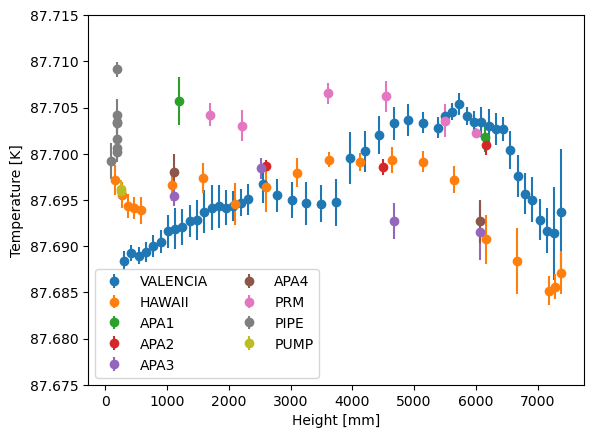

In [91]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
# apa.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 45, 0), tend=datetime.datetime(2024, 12, 2, 6, 0, 0))
pipe.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
pp.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="VALENCIA")
plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='o', label="HAWAII")
mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)

print(apa.profiles.loc[mask1, "temp"].values)
plt.errorbar(
    apa.profiles.loc[mask1, "Y"].values,
    apa.profiles.loc[mask1, "temp"].values,
    yerr=apa.profiles.loc[mask1, "err"].values,
    fmt='o',
    label="APA1"
)
plt.errorbar(
    apa.profiles.loc[mask2, "Y"].values,
    apa.profiles.loc[mask2, "temp"].values,
    yerr=apa.profiles.loc[mask2, "err"].values,
    fmt='o',
    label="APA2"
)
plt.errorbar(
    apa.profiles.loc[mask3, "Y"].values,
    apa.profiles.loc[mask3, "temp"].values,
    yerr=apa.profiles.loc[mask3, "err"].values,
    fmt='o',
    label="APA3"
)
plt.errorbar(
    apa.profiles.loc[mask4, "Y"].values,
    apa.profiles.loc[mask4, "temp"].values,
    yerr=apa.profiles.loc[mask4, "err"].values,
    fmt='o',
    label="APA4"
)
plt.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, fmt='o', label="PRM")
plt.errorbar(pipe.profiles["Y"].values, pipe.profiles["temp"].values, yerr=pipe.profiles["err"].values, fmt='o', label="PIPE")
plt.errorbar(pp.profiles["Y"].values, pp.profiles["temp"].values, yerr=pp.profiles["err"].values, fmt='o', label="PUMP")
print(pp.profiles["temp"].values)
plt.ylim(87.675, 87.715)
plt.legend(ncol=2);
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")

[87.70180147 87.70573275]


Text(0, 0.5, 'Temperature [K]')

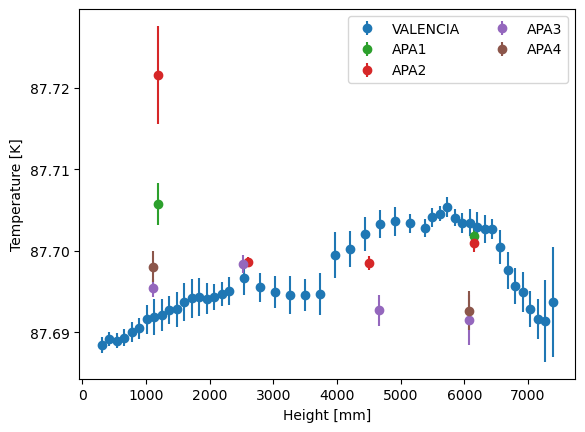

In [34]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
pipe.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
pp.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="VALENCIA")
mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)

print(apa.profiles.loc[mask1, "temp"].values)
plt.errorbar(
    apa.profiles.loc[mask1, "Y"].values,
    apa.profiles.loc[mask1, "temp"].values,
    yerr=apa.profiles.loc[mask1, "err"].values,
    fmt='o',
    label="APA1",
    color="tab:green"
)
plt.errorbar(
    apa.profiles.loc[mask2, "Y"].values,
    apa.profiles.loc[mask2, "temp"].values,
    yerr=apa.profiles.loc[mask2, "err"].values,
    fmt='o',
    label="APA2",
    color="tab:red"
)
plt.errorbar(
    apa.profiles.loc[mask3, "Y"].values,
    apa.profiles.loc[mask3, "temp"].values,
    yerr=apa.profiles.loc[mask3, "err"].values,
    fmt='o',
    label="APA3",
    color="tab:purple"
)
plt.errorbar(
    apa.profiles.loc[mask4, "Y"].values,
    apa.profiles.loc[mask4, "temp"].values,
    yerr=apa.profiles.loc[mask4, "err"].values,
    fmt='o',
    label="APA4",
    color="tab:brown"
)
# plt.ylim(87.595, 87.65)
plt.legend(ncol=2);
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")

[87.87426248 87.87446788]


Text(0, 0.5, 'Temperature [K]')

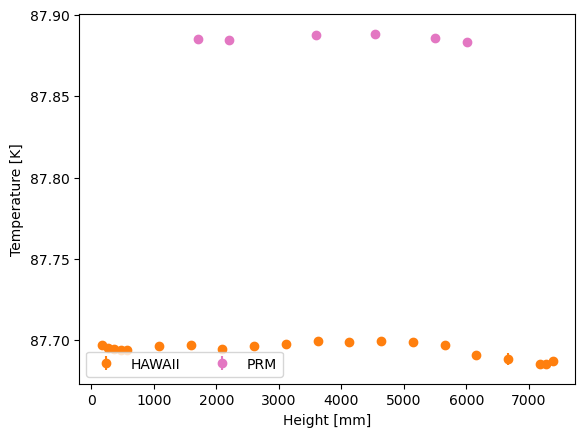

In [36]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
pipe.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
pp.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
# plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="VALENCIA")
plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='o', label="HAWAII", color="tab:orange")
mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)

# print(apa.profiles.loc[mask1, "temp"].values)
# plt.errorbar(
#     apa.profiles.loc[mask1, "Y"].values,
#     apa.profiles.loc[mask1, "temp"].values,
#     yerr=apa.profiles.loc[mask1, "err"].values,
#     fmt='o',
#     label="APA1"
# )
# plt.errorbar(
#     apa.profiles.loc[mask2, "Y"].values,
#     apa.profiles.loc[mask2, "temp"].values,
#     yerr=apa.profiles.loc[mask2, "err"].values,
#     fmt='o',
#     label="APA2"
# )
# plt.errorbar(
#     apa.profiles.loc[mask3, "Y"].values,
#     apa.profiles.loc[mask3, "temp"].values,
#     yerr=apa.profiles.loc[mask3, "err"].values,
#     fmt='o',
#     label="APA3"
# )
# plt.errorbar(
#     apa.profiles.loc[mask4, "Y"].values,
#     apa.profiles.loc[mask4, "temp"].values,
#     yerr=apa.profiles.loc[mask4, "err"].values,
#     fmt='o',
#     label="APA4"
# )
plt.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values + 0.005, yerr=prm.profiles["err"].values, fmt='o', label="PRM", color="tab:pink")
# plt.errorbar(pipe.profiles["Y"].values, pipe.profiles["temp"].values + 0.005, yerr=pipe.profiles["err"].values, fmt='o', label="PIPE")
# plt.errorbar(pp.profiles["Y"].values, pp.profiles["temp"].values + 0.005, yerr=pp.profiles["err"].values, fmt='o', label="PUMP")
print(pp.profiles["temp"].values)
# plt.ylim(87.595, 87.65)
plt.legend(ncol=2);
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")

[87.70180147 87.70573275]


Text(0, 0.5, 'Temperature [K]')

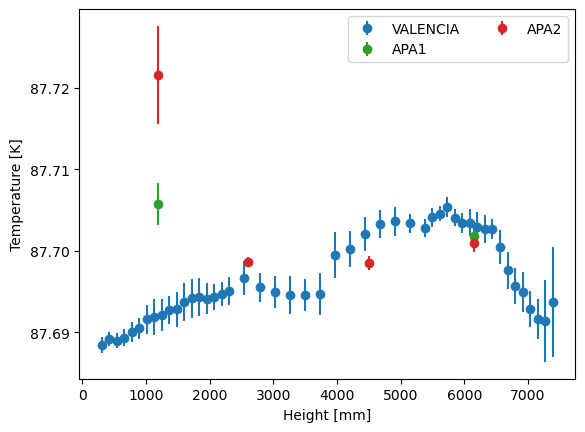

In [38]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
pipe.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
pp.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="VALENCIA")
# plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='o', label="HAWAII")
mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)

print(apa.profiles.loc[mask1, "temp"].values)
plt.errorbar(
    apa.profiles.loc[mask1, "Y"].values,
    apa.profiles.loc[mask1, "temp"].values,
    yerr=apa.profiles.loc[mask1, "err"].values,
    fmt='o',
    label="APA1",
    color="tab:green"
)
plt.errorbar(
    apa.profiles.loc[mask2, "Y"].values,
    apa.profiles.loc[mask2, "temp"].values,
    yerr=apa.profiles.loc[mask2, "err"].values,
    fmt='o',
    label="APA2",
    color="tab:red"
)
# plt.errorbar(
#     apa.profiles.loc[mask3, "Y"].values,
#     apa.profiles.loc[mask3, "temp"].values,
#     yerr=apa.profiles.loc[mask3, "err"].values,
#     fmt='o',
#     label="APA3"
# )
# plt.errorbar(
#     apa.profiles.loc[mask4, "Y"].values,
#     apa.profiles.loc[mask4, "temp"].values,
#     yerr=apa.profiles.loc[mask4, "err"].values,
#     fmt='o',
#     label="APA4"
# )
mask5 = pipe.profiles["name"].str.contains("U", na=False)
# plt.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values + 0.005, yerr=prm.profiles["err"].values, fmt='o', label="PRM")
#plt.errorbar(pipe.profiles.loc[mask5, "Y"].values, pipe.profiles.loc[mask5, "temp"].values + 0.005, yerr=pipe.profiles.loc[mask5, "err"].values, fmt='o', label="PIPE", color="tab:grey")
# plt.errorbar(pp.profiles["Y"].values, pp.profiles["temp"].values + 0.005, yerr=pp.profiles["err"].values, fmt='o', label="PUMP")
# plt.ylim(87.595, 87.65)
plt.legend(ncol=2);
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")
# plt.savefig("/eos/user/j/jcapotor/DUNE-IFIC/Experiments/ProtoDUNE-HD/Operation/Plots/temp_homo_stab/normal_operation_saleve.pdf", format="pdf")

[87.62009846 87.62401978]


Text(0, 0.5, 'Temperature [K]')

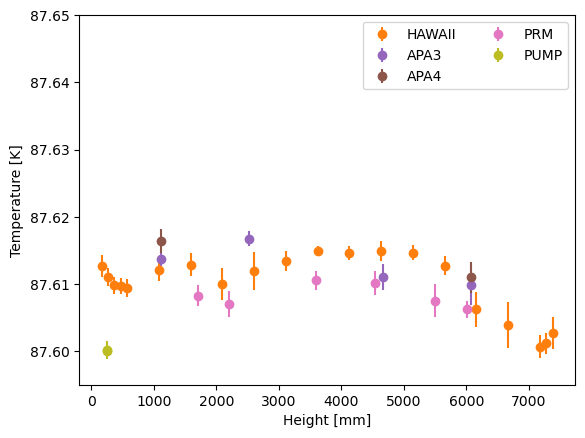

In [ ]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
pipe.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
pp.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
#plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="VALENCIA")
plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='o', label="HAWAII", color="tab:orange")
mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)

print(apa.profiles.loc[mask1, "temp"].values)
# plt.errorbar(
#     apa.profiles.loc[mask1, "Y"].values,
#     apa.profiles.loc[mask1, "temp"].values,
#     yerr=apa.profiles.loc[mask1, "err"].values,
#     fmt='o',
#     label="APA1"
# )
# plt.errorbar(
#     apa.profiles.loc[mask2, "Y"].values,
#     apa.profiles.loc[mask2, "temp"].values,
#     yerr=apa.profiles.loc[mask2, "err"].values,
#     fmt='o',
#     label="APA2"
# )
plt.errorbar(
    apa.profiles.loc[mask3, "Y"].values,
    apa.profiles.loc[mask3, "temp"].values,
    yerr=apa.profiles.loc[mask3, "err"].values,
    fmt='o',
    label="APA3",
    color="tab:purple"
)
plt.errorbar(
    apa.profiles.loc[mask4, "Y"].values,
    apa.profiles.loc[mask4, "temp"].values,
    yerr=apa.profiles.loc[mask4, "err"].values,
    fmt='o',
    label="APA4",
    color="tab:brown"
)
mask5 = pipe.profiles["name"].str.contains("M", na=False)
plt.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, fmt='o', label="PRM", color="tab:pink")
#plt.errorbar(pipe.profiles.loc[mask5, "Y"].values, pipe.profiles.loc[mask5, "temp"].values + 0.005, yerr=pipe.profiles.loc[mask5, "err"].values, fmt='o', label="PIPE", color="tab:grey")
# plt.errorbar(pp.profiles["Y"].values, pp.profiles["temp"].values, yerr=pp.profiles["err"].values, fmt='o', label="PUMP", color="tab:olive")
plt.ylim(87.595, 87.65)
plt.legend(ncol=2);
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")
plt.savefig("/eos/user/j/jcapotor/DUNE-IFIC/Experiments/ProtoDUNE-HD/Operation/Plots/temp_homo_stab/normal_operation_jura.pdf", format="pdf")